In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import re

# =========================
# 0. 基本設定
# =========================
poi_lat = 25.0190099143756
poi_lon = 121.53137177116402

# 你給的 GWL1.5 路徑（Windows 路徑請加 r）
tmean_folder = Path(r"\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_平均溫\GWL1.5")
tmax_folder  = Path(r"\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最高溫\GWL1.5")
tmin_folder  = Path(r"\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最低溫\GWL1.5")

INVALID_VALUE = -99.9

# 先指定同一模式
model_name = "ACCESS-CM2"

# 你目前要看的 SSP
target_ssps = ["ssp126", "ssp245", "ssp370", "ssp585"]


# =========================
# 1. 基本工具函式
# =========================
def get_files_for_model_and_ssp(folder: Path, model_name: str, ssp_name: str):
    """
    從 GWL1.5 資料夾內抓出某個 model + ssp 的所有 csv
    """
    files = sorted(folder.glob("*.csv"))
    matched = [
        f for f in files
        if (ssp_name in f.name) and (model_name in f.name)
    ]

    def extract_year_from_filename(fp):
        m = re.search(r"_(\d{4})\.csv$", fp.name)
        return int(m.group(1)) if m else -1

    matched = sorted(matched, key=extract_year_from_filename)
    return matched


def read_csv_with_fallback(csv_path: Path):
    """
    自動嘗試常見編碼
    """
    encodings = ["utf-8", "utf-8-sig", "big5"]
    last_error = None

    for enc in encodings:
        try:
            return pd.read_csv(csv_path, encoding=enc)
        except Exception as e:
            last_error = e

    raise last_error


def read_point_daily_series_from_csv(csv_path: Path, poi_lon: float, poi_lat: float):
    """
    適用 AR6 日資料格式：
    - 前兩欄：LON, LAT
    - 後面欄位：YYYYMMDD
    - 每列：一個格點
    """
    df = read_csv_with_fallback(csv_path)

    # 欄名標準化
    original_cols = list(df.columns)
    cols_upper = [str(c).upper() for c in df.columns]
    df.columns = cols_upper

    lon_col = df.columns[0]
    lat_col = df.columns[1]

    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")

    # 找最近格點
    dist = np.sqrt((df[lon_col] - poi_lon) ** 2 + (df[lat_col] - poi_lat) ** 2)
    idx = dist.idxmin()
    row = df.loc[idx]

    # 後面全是日期欄
    date_cols = df.columns[2:]
    dates = pd.to_datetime(date_cols, format="%Y%m%d", errors="coerce")
    values = pd.to_numeric(row[date_cols], errors="coerce").replace(INVALID_VALUE, np.nan)

    s = pd.Series(values.values, index=dates)
    s = s[~s.index.isna()].sort_index()

    return s, float(row[lon_col]), float(row[lat_col])


def load_full_daily_series(folder: Path, model_name: str, ssp_name: str, poi_lon: float, poi_lat: float):
    """
    把同一個 model + ssp 在 GWL1.5 資料夾中的所有年份檔案串成完整日序列
    """
    files = get_files_for_model_and_ssp(folder, model_name, ssp_name)
    if len(files) == 0:
        raise FileNotFoundError(f"{folder} 裡找不到 {ssp_name} + {model_name} 的檔案")

    series_list = []
    nearest_lon = None
    nearest_lat = None

    for f in files:
        s, lon0, lat0 = read_point_daily_series_from_csv(f, poi_lon, poi_lat)
        series_list.append(s)
        nearest_lon = lon0
        nearest_lat = lat0

    full = pd.concat(series_list, axis=0)
    full = full[~full.index.duplicated(keep="first")]
    full = full.sort_index()

    return full, nearest_lon, nearest_lat


# =========================
# 2. 月統計
# =========================
def calc_monthly_stats(tmean_series: pd.Series, tmax_series: pd.Series) -> pd.DataFrame:
    """
    先算月統計，後面再合季
    """
    df = pd.DataFrame({
        "tmean": tmean_series,
        "tmax": tmax_series
    }).dropna(subset=["tmean", "tmax"], how="all").sort_index()

    # 年月
    df["year"] = df.index.year
    df["month"] = df.index.month
    df["ym"] = df.index.to_period("M")

    monthly = df.groupby("ym").agg(
        tmean_monthly_mean=("tmean", "mean"),
        tmax_gt31_days=("tmax", lambda x: (x > 31).sum()),
        tmax_ge35_days=("tmax", lambda x: (x >= 35).sum()),
        tmax_ge40_days=("tmax", lambda x: (x >= 40).sum()),
        n_days=("tmax", "count"),
    )

    monthly["year"] = monthly.index.year
    monthly["month"] = monthly.index.month

    return monthly.reset_index(drop=False)


# =========================
# 3. 月轉季
# =========================
def month_to_season(month: int):
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    else:
        return "SON"


def assign_season_year(year: int, month: int):
    """
    DJF 讓 12 月歸到下一年的冬季
    例如 2030-12 算到 2031-DJF
    """
    if month == 12:
        return year + 1
    return year


def calc_seasonal_stats_from_monthly(monthly_df: pd.DataFrame) -> pd.DataFrame:
    df = monthly_df.copy()

    df["season"] = df["month"].apply(month_to_season)
    df["season_year"] = df.apply(lambda r: assign_season_year(int(r["year"]), int(r["month"])), axis=1)

    seasonal = df.groupby(["season_year", "season"]).agg(
        tmean_seasonal_mean=("tmean_monthly_mean", "mean"),
        tmax_gt31_days=("tmax_gt31_days", "sum"),
        tmax_ge35_days=("tmax_ge35_days", "sum"),
        tmax_ge40_days=("tmax_ge40_days", "sum"),
        n_days=("n_days", "sum"),
    ).reset_index()

    # 排序
    season_order = {"DJF": 1, "MAM": 2, "JJA": 3, "SON": 4}
    seasonal["season_order"] = seasonal["season"].map(season_order)
    seasonal = seasonal.sort_values(["season_year", "season_order"]).drop(columns="season_order")

    return seasonal


# =========================
# 4. 主流程：同一模式，不同 SSP
# =========================
monthly_results = {}
seasonal_results = {}
grid_info = {}

for ssp in target_ssps:
    try:
        tmean_series, lon0, lat0 = load_full_daily_series(
            tmean_folder, model_name, ssp, poi_lon, poi_lat
        )
        tmax_series, _, _ = load_full_daily_series(
            tmax_folder, model_name, ssp, poi_lon, poi_lat
        )

        monthly_df = calc_monthly_stats(tmean_series, tmax_series)
        seasonal_df = calc_seasonal_stats_from_monthly(monthly_df)

        monthly_results[ssp] = monthly_df
        seasonal_results[ssp] = seasonal_df
        grid_info[ssp] = {"lon": lon0, "lat": lat0}

        print(f"[OK] {model_name} | {ssp}")
        print(f"     nearest grid = ({lat0:.4f}, {lon0:.4f})")
        print(f"     monthly rows = {len(monthly_df)}, seasonal rows = {len(seasonal_df)}")

    except Exception as e:
        print(f"[SKIP] {model_name} | {ssp}: {e}")

[OK] ACCESS-CM2 | ssp126
     nearest grid = (25.0200, 121.5300)
     monthly rows = 240, seasonal rows = 81
[OK] ACCESS-CM2 | ssp245
     nearest grid = (25.0200, 121.5300)
     monthly rows = 240, seasonal rows = 81
[OK] ACCESS-CM2 | ssp370
     nearest grid = (25.0200, 121.5300)
     monthly rows = 240, seasonal rows = 81
[OK] ACCESS-CM2 | ssp585
     nearest grid = (25.0200, 121.5300)
     monthly rows = 240, seasonal rows = 81


In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from pathlib import Path

save_path = Path(r"\Users\user\OneDrive\桌面\Climate_project\程式作業\Daxue＿village\code")

ssp_order = ["ssp126", "ssp245", "ssp370", "ssp585"]
season_order = ["DJF", "MAM", "JJA", "SON"]

def build_seasonal_summary_table(seasonal_results, ssp_order=None, season_order=None):
    if ssp_order is None:
        ssp_order = sorted(seasonal_results.keys())
    if season_order is None:
        season_order = ["DJF", "MAM", "JJA", "SON"]

    summary = {}

    for ssp in ssp_order:
        sdf = seasonal_results[ssp].copy()

        tmp = (
            sdf.groupby("season")
            .agg(
                tmean_seasonal_mean=("tmean_seasonal_mean", "mean"),
                tmax_gt31_days=("tmax_gt31_days", "mean"),
                tmax_ge35_days=("tmax_ge35_days", "mean"),
                tmax_ge40_days=("tmax_ge40_days", "mean"),
            )
            .reindex(season_order)
        )

        summary[ssp] = tmp

    return summary


def plot_seasonal_bar_charts(seasonal_results, model_name, save_path=None):
    seasonal_summary = build_seasonal_summary_table(
        seasonal_results,
        ssp_order=ssp_order,
        season_order=season_order
    )

    metrics = [
        ("tmean_seasonal_mean", "Seasonal Mean Tmean", "°C"),
        ("tmax_gt31_days", "Seasonal Days with Tmax > 31°C", "Days"),
        ("tmax_ge35_days", "Seasonal Days with Tmax ≥ 35°C", "Days"),
        ("tmax_ge40_days", "Seasonal Days with Tmax ≥ 40°C", "Days"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    x = np.arange(len(season_order))
    width = 0.18

    colors = {
        "ssp126": "#1f77b4",
        "ssp245": "#2ca02c",
        "ssp370": "#ff7f0e",
        "ssp585": "#d62728",
    }

    for ax, (metric, title, ylabel) in zip(axes, metrics):
        for i, ssp in enumerate(ssp_order):
            vals = seasonal_summary[ssp][metric].values
            ax.bar(
                x + (i - 1.5) * width,
                vals,
                width=width,
                label=ssp,
                color=colors.get(ssp, None),
                alpha=0.85
            )

        ax.set_xticks(x)
        ax.set_xticklabels(season_order)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(axis="y", alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4)
    fig.suptitle(f"Daxue_village - {model_name} Seasonal Cockroach Thermal Metrics", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path is not None:
        from pathlib import Path
        save_path = Path(save_path)
        filename = f"Daxue_village_{model_name}_Seasonal_Cockroach_Thermal_Metrics.png"
        plt.savefig(save_path / filename, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_path / filename}")

    plt.show()

In [29]:
def build_monthly_threshold_climatology(monthly_results, ssp_order=None):
    if ssp_order is None:
        ssp_order = sorted(monthly_results.keys())

    climatology = {}

    for ssp in ssp_order:
        mdf = monthly_results[ssp].copy()

        tmp = (
            mdf.groupby("month")
            .agg(
                tmax_gt31_days=("tmax_gt31_days", "mean"),
                tmax_ge35_days=("tmax_ge35_days", "mean"),
                tmax_ge40_days=("tmax_ge40_days", "mean"),
            )
            .reindex(range(1, 13))
        )

        climatology[ssp] = tmp

    return climatology


def plot_monthly_threshold_lines(monthly_results, model_name, save_path=None):
    monthly_clim = build_monthly_threshold_climatology(
        monthly_results,
        ssp_order=ssp_order
    )

    metrics = [
        ("tmax_gt31_days", "Monthly Mean Days with Tmax > 31°C", "Days / Month"),
        ("tmax_ge35_days", "Monthly Mean Days with Tmax ≥ 35°C", "Days / Month"),
        ("tmax_ge40_days", "Monthly Mean Days with Tmax ≥ 40°C", "Days / Month"),
    ]

    colors = {
        "ssp126": "#1f77b4",
        "ssp245": "#2ca02c",
        "ssp370": "#ff7f0e",
        "ssp585": "#d62728",
    }

    month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

    for ax, (metric, title, ylabel) in zip(axes, metrics):
        for ssp in ssp_order:
            vals = monthly_clim[ssp][metric].values

            ax.plot(
                range(1, 13),
                vals,
                marker="o",
                linewidth=2,
                label=ssp,
                color=colors.get(ssp, None)
            )

        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

    axes[-1].set_xticks(range(1, 13))
    axes[-1].set_xticklabels(month_labels)
    axes[0].legend(ncol=4, loc="lower center")

    fig.suptitle(f"Daxue_village - {model_name} Monthly Cockroach Heat Threshold Days", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save_path is not None:
        from pathlib import Path
        save_path = Path(save_path)
        filename = f"Daxue_village_{model_name}_Monthly_Cockroach_Heat_Threshold_Days.png"
        plt.savefig(save_path / filename, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_path / filename}")

    plt.show()

[OK] TaiESM1 | ssp126
     nearest grid = (25.0200, 121.5300)
     monthly rows = 180, seasonal rows = 61
[OK] TaiESM1 | ssp245
     nearest grid = (25.0200, 121.5300)
     monthly rows = 156, seasonal rows = 53
[OK] TaiESM1 | ssp370
     nearest grid = (25.0200, 121.5300)
     monthly rows = 132, seasonal rows = 45
[OK] TaiESM1 | ssp585
     nearest grid = (25.0200, 121.5300)
     monthly rows = 180, seasonal rows = 61


C:\Users\user\AppData\Local\Temp\ipykernel_23864\3883964809.py:262: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdf.groupby("season")
C:\Users\user\AppData\Local\Temp\ipykernel_23864\3883964809.py:262: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdf.groupby("season")
C:\Users\user\AppData\Local\Temp\ipykernel_23864\3883964809.py:262: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdf.groupby("season")
C:\Users\user\Ap

✅ Saved: \Users\user\OneDrive\桌面\Climate_project\程式作業\Daxue＿village\code\Daxue_village_TaiESM1_Seasonal_Cockroach_Thermal_Metrics_2020_2034.png


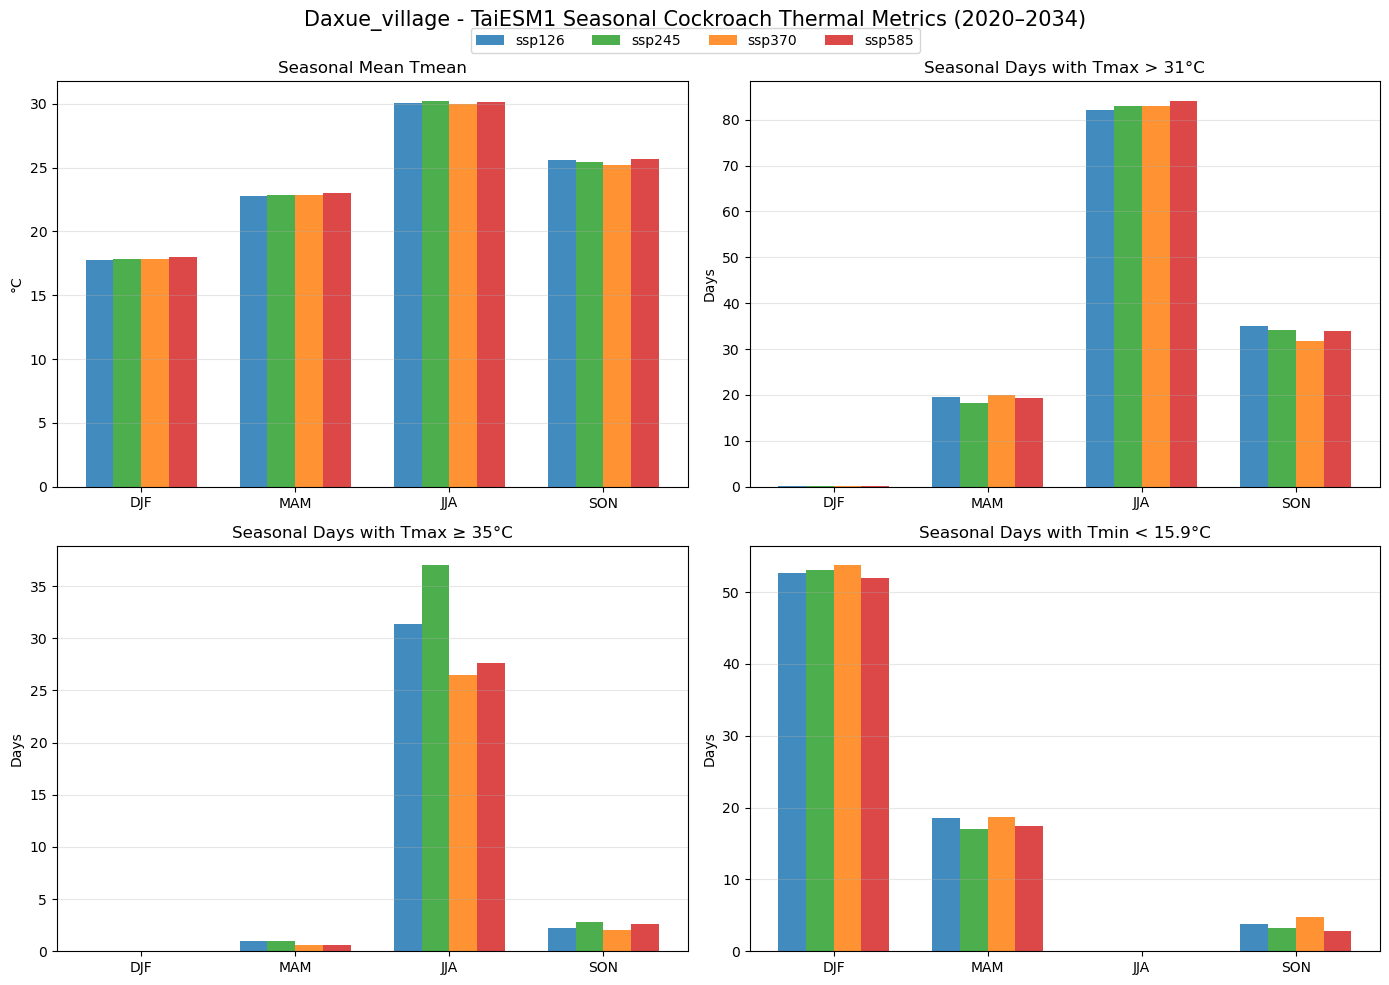

✅ Saved: \Users\user\OneDrive\桌面\Climate_project\程式作業\Daxue＿village\code\Daxue_village_TaiESM1_Monthly_Cockroach_Thermal_Threshold_Days_2020_2034.png


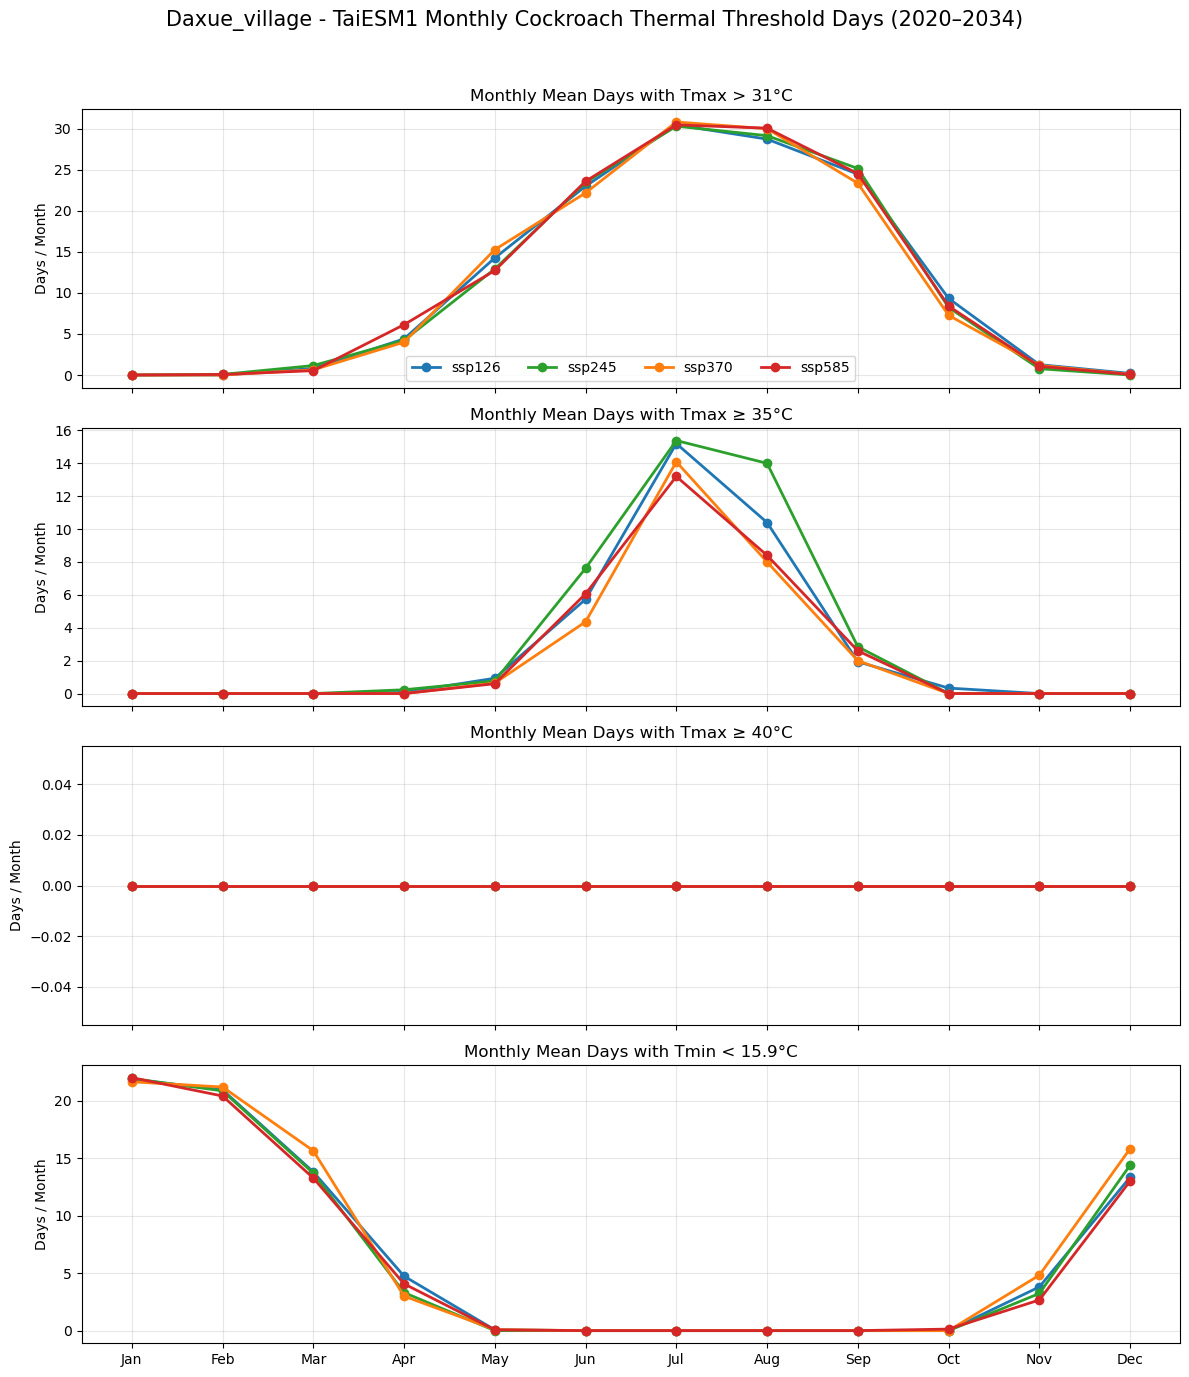

In [75]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# =========================================================
# 0. 基本設定
# =========================================================
poi_lat = 25.0190099143756
poi_lon = 121.53137177116402

# 你的資料路徑（Windows 建議用 raw string）
tmean_folder = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_平均溫\GWL1.5")
tmax_folder  = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最高溫\GWL1.5")
tmin_folder  = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最低溫\GWL1.5")

# 圖片輸出路徑
save_path = Path(r"\Users\user\OneDrive\桌面\Climate_project\程式作業\Daxue＿village\code")
save_path.mkdir(parents=True, exist_ok=True)

# 分析模式
model_name = "TaiESM1"  # ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]

# 分析 SSP
target_ssps = ["ssp126", "ssp245", "ssp370", "ssp585"]

# 年份限制
start_year = 2020
end_year = 2034

INVALID_VALUE = -99.9

ssp_colors = {
    "ssp126": "#1f77b4",  # blue
    "ssp245": "#2ca02c",  # green
    "ssp370": "#ff7f0e",  # orange
    "ssp585": "#d62728",  # red
}

season_order = ["DJF", "MAM", "JJA", "SON"]


# =========================================================
# 1. 讀檔工具
# =========================================================
def read_csv_with_fallback(csv_path: Path):
    encodings = ["utf-8", "utf-8-sig", "big5"]
    last_error = None

    for enc in encodings:
        try:
            return pd.read_csv(csv_path, encoding=enc)
        except Exception as e:
            last_error = e

    raise last_error


def extract_year_from_filename(fp: Path):
    m = re.search(r"_(\d{4})\.csv$", fp.name)
    return int(m.group(1)) if m else -1


def get_files_for_model_and_ssp(folder: Path, model_name: str, ssp_name: str):
    files = sorted(folder.glob("*.csv"))
    matched = [
        f for f in files
        if (ssp_name in f.name) and (model_name in f.name)
    ]
    matched = sorted(matched, key=extract_year_from_filename)
    return matched


def read_point_daily_series_from_csv(csv_path: Path, poi_lon: float, poi_lat: float):
    """
    適用格式：
    LON | LAT | 20200101 | 20200102 | ...
    """
    df = read_csv_with_fallback(csv_path)

    cols_upper = [str(c).upper() for c in df.columns]
    df.columns = cols_upper

    lon_col = df.columns[0]
    lat_col = df.columns[1]

    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")

    # 找最近格點
    dist = np.sqrt((df[lon_col] - poi_lon) ** 2 + (df[lat_col] - poi_lat) ** 2)
    idx = dist.idxmin()
    row = df.loc[idx]

    date_cols = df.columns[2:]
    dates = pd.to_datetime(date_cols, format="%Y%m%d", errors="coerce")
    values = pd.to_numeric(row[date_cols], errors="coerce").replace(INVALID_VALUE, np.nan)

    s = pd.Series(values.values, index=dates)
    s = s[~s.index.isna()].sort_index()

    return s, float(row[lon_col]), float(row[lat_col])


def load_full_daily_series(folder: Path, model_name: str, ssp_name: str, poi_lon: float, poi_lat: float):
    files = get_files_for_model_and_ssp(folder, model_name, ssp_name)
    if len(files) == 0:
        raise FileNotFoundError(f"{folder} 裡找不到 {ssp_name} + {model_name} 的檔案")

    series_list = []
    nearest_lon = None
    nearest_lat = None

    for f in files:
        s, lon0, lat0 = read_point_daily_series_from_csv(f, poi_lon, poi_lat)
        series_list.append(s)
        nearest_lon = lon0
        nearest_lat = lat0

    full = pd.concat(series_list, axis=0)
    full = full[~full.index.duplicated(keep="first")]
    full = full.sort_index()

    return full, nearest_lon, nearest_lat


# =========================================================
# 2. 月統計與季統計
# =========================================================
def calc_monthly_stats(tmean_series, tmax_series, tmin_series):
    df = pd.DataFrame({
        "tmean": tmean_series,
        "tmax": tmax_series,
        "tmin": tmin_series
    }).dropna(how="all").sort_index()

    # 限制年份
    df = df[(df.index.year >= start_year) & (df.index.year <= end_year)].copy()

    df["year"] = df.index.year
    df["month"] = df.index.month
    df["ym"] = df.index.to_period("M")

    monthly = df.groupby("ym").agg(
        # 平均溫
        tmean_monthly_mean=("tmean", "mean"),

        # 高溫條件
        tmax_gt31_days=("tmax", lambda x: (x > 31).sum()),
        tmax_ge35_days=("tmax", lambda x: (x >= 35).sum()),
        tmax_ge40_days=("tmax", lambda x: (x >= 40).sum()),

        # 冷壓力
        tmin_lt15_9_days=("tmin", lambda x: (x < 15.9).sum()),

        n_days=("tmean", "count"),
    )

    monthly["year"] = monthly.index.year
    monthly["month"] = monthly.index.month

    return monthly.reset_index(drop=False)


def month_to_season(month):
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    else:
        return "SON"


def assign_season_year(year, month):
    # 12 月歸到下一年冬季
    if month == 12:
        return year + 1
    return year


def calc_seasonal_stats_from_monthly(monthly_df):
    df = monthly_df.copy()

    df["season"] = df["month"].apply(month_to_season)
    df["season_year"] = df.apply(
        lambda r: assign_season_year(int(r["year"]), int(r["month"])),
        axis=1
    )

    seasonal = df.groupby(["season_year", "season"]).agg(
        tmean_seasonal_mean=("tmean_monthly_mean", "mean"),
        tmax_gt31_days=("tmax_gt31_days", "sum"),
        tmax_ge35_days=("tmax_ge35_days", "sum"),
        tmax_ge40_days=("tmax_ge40_days", "sum"),
        tmin_lt15_9_days=("tmin_lt15_9_days", "sum"),
        n_days=("n_days", "sum"),
    ).reset_index()

    seasonal["season"] = pd.Categorical(seasonal["season"], categories=season_order, ordered=True)
    seasonal = seasonal.sort_values(["season_year", "season"])

    return seasonal


# =========================================================
# 3. 主流程：同一模式，不同 SSP
# =========================================================
monthly_results = {}
seasonal_results = {}
grid_info = {}

for ssp in target_ssps:
    try:
        tmean_series, lon0, lat0 = load_full_daily_series(
            tmean_folder, model_name, ssp, poi_lon, poi_lat
        )
        tmax_series, _, _ = load_full_daily_series(
            tmax_folder, model_name, ssp, poi_lon, poi_lat
        )
        tmin_series, _, _ = load_full_daily_series(
            tmin_folder, model_name, ssp, poi_lon, poi_lat
        )

        # 限制年份
        tmean_series = tmean_series[f"{start_year}":f"{end_year}"]
        tmax_series  = tmax_series[f"{start_year}":f"{end_year}"]
        tmin_series  = tmin_series[f"{start_year}":f"{end_year}"]

        monthly_df = calc_monthly_stats(tmean_series, tmax_series, tmin_series)
        seasonal_df = calc_seasonal_stats_from_monthly(monthly_df)

        monthly_results[ssp] = monthly_df
        seasonal_results[ssp] = seasonal_df
        grid_info[ssp] = {"lon": lon0, "lat": lat0}

        print(f"[OK] {model_name} | {ssp}")
        print(f"     nearest grid = ({lat0:.4f}, {lon0:.4f})")
        print(f"     monthly rows = {len(monthly_df)}, seasonal rows = {len(seasonal_df)}")

    except Exception as e:
        print(f"[SKIP] {model_name} | {ssp}: {e}")


# =========================================================
# 4. 季節摘要表
# =========================================================
def build_seasonal_summary_table(seasonal_results, ssp_order=None, season_order=None):
    if ssp_order is None:
        ssp_order = sorted(seasonal_results.keys())
    if season_order is None:
        season_order = ["DJF", "MAM", "JJA", "SON"]

    summary = {}

    for ssp in ssp_order:
        sdf = seasonal_results[ssp].copy()

        tmp = (
            sdf.groupby("season")
            .agg(
                tmean_seasonal_mean=("tmean_seasonal_mean", "mean"),
                tmax_gt31_days=("tmax_gt31_days", "mean"),
                tmax_ge35_days=("tmax_ge35_days", "mean"),
                tmax_ge40_days=("tmax_ge40_days", "mean"),
                tmin_lt15_9_days=("tmin_lt15_9_days", "mean"),
            )
            .reindex(season_order)
        )

        summary[ssp] = tmp

    return summary


# =========================================================
# 5. 圖 1：季節長條圖
# =========================================================
def plot_seasonal_bar_charts(seasonal_results, model_name, save_path=None):
    seasonal_summary = build_seasonal_summary_table(
        seasonal_results,
        ssp_order=target_ssps,
        season_order=season_order
    )

    metrics = [
        ("tmean_seasonal_mean", "Seasonal Mean Tmean", "°C"),
        ("tmax_gt31_days", "Seasonal Days with Tmax > 31°C", "Days"),
        ("tmax_ge35_days", "Seasonal Days with Tmax ≥ 35°C", "Days"),
        ("tmin_lt15_9_days", "Seasonal Days with Tmin < 15.9°C", "Days"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    x = np.arange(len(season_order))
    width = 0.18

    for ax, (metric, title, ylabel) in zip(axes, metrics):
        for i, ssp in enumerate(target_ssps):
            vals = seasonal_summary[ssp][metric].values
            ax.bar(
                x + (i - 1.5) * width,
                vals,
                width=width,
                label=ssp,
                color=ssp_colors.get(ssp, None),
                alpha=0.85
            )

        ax.set_xticks(x)
        ax.set_xticklabels(season_order)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(axis="y", alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4,bbox_to_anchor=(0.5, 0.93))
    fig.suptitle(f"Daxue_village - {model_name} Seasonal Cockroach Thermal Metrics (2020–2034)", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        filename = f"Daxue_village_{model_name}_Seasonal_Cockroach_Thermal_Metrics_2020_2034.png"
        save_file = save_path / filename
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()


# =========================================================
# 6. 圖 2：每月閾值折線圖
# =========================================================
def build_monthly_threshold_climatology(monthly_results, ssp_order=None):
    if ssp_order is None:
        ssp_order = sorted(monthly_results.keys())

    climatology = {}

    for ssp in ssp_order:
        mdf = monthly_results[ssp].copy()

        tmp = (
            mdf.groupby("month")
            .agg(
                tmax_gt31_days=("tmax_gt31_days", "mean"),
                tmax_ge35_days=("tmax_ge35_days", "mean"),
                tmax_ge40_days=("tmax_ge40_days", "mean"),
                tmin_lt15_9_days=("tmin_lt15_9_days", "mean"),
            )
            .reindex(range(1, 13))
        )

        climatology[ssp] = tmp

    return climatology


def plot_monthly_threshold_lines(monthly_results, model_name, save_path=None):
    monthly_clim = build_monthly_threshold_climatology(
        monthly_results,
        ssp_order=target_ssps
    )

    metrics = [
        ("tmax_gt31_days", "Monthly Mean Days with Tmax > 31°C", "Days / Month"),
        ("tmax_ge35_days", "Monthly Mean Days with Tmax ≥ 35°C", "Days / Month"),
        ("tmax_ge40_days", "Monthly Mean Days with Tmax ≥ 40°C", "Days / Month"),
        ("tmin_lt15_9_days", "Monthly Mean Days with Tmin < 15.9°C", "Days / Month"),
    ]

    month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

    for ax, (metric, title, ylabel) in zip(axes, metrics):
        for ssp in target_ssps:
            vals = monthly_clim[ssp][metric].values

            ax.plot(
                range(1, 13),
                vals,
                marker="o",
                linewidth=2,
                label=ssp,
                color=ssp_colors.get(ssp, None)
            )

        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

    axes[-1].set_xticks(range(1, 13))
    axes[-1].set_xticklabels(month_labels)
    axes[0].legend(ncol=4, loc="lower center")

    fig.suptitle(f"Daxue_village - {model_name} Monthly Cockroach Thermal Threshold Days (2020–2034)", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save_path is not None:
        filename = f"Daxue_village_{model_name}_Monthly_Cockroach_Thermal_Threshold_Days_2020_2034.png"
        save_file = save_path / filename
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()

In [ ]:
# =========================================================
# 7. 輸出表格 + 畫圖
# =========================================================
# 先看一個 SSP 的月資料 / 季資料
# print(monthly_results["ssp245"].head())
# print(seasonal_results["ssp245"].head())

plot_seasonal_bar_charts(
    seasonal_results=seasonal_results,
    model_name=model_name,
    save_path=save_path
)

plot_monthly_threshold_lines(
    monthly_results=monthly_results,
    model_name=model_name,
    save_path=save_path
)

In [44]:
def safe_filename(text):
    return (
        text
        .replace(" ", "_")
        .replace(">", "gt")
        .replace("<", "lt")
        .replace("=", "eq")
        .replace("°", "")
    )
    

In [46]:
title = "Seasonal Days with Tmax > 31C"
safe_title = safe_filename(title)

In [76]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

season_order = ["DJF", "MAM", "JJA", "SON"]

ssp_colors = {
    "ssp126": "#1f77b4",
    "ssp245": "#2ca02c",
    "ssp370": "#ff7f0e",
    "ssp585": "#d62728",
}

def plot_seasonal_interannual_timeseries(
    seasonal_results,
    metric,
    title,
    ylabel,
    model_name,
    save_path=None,
    ylim=None
):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    axes = axes.flatten()

    for i, season in enumerate(season_order):
        ax = axes[i]

        for ssp in target_ssps:
            if ssp not in seasonal_results:
                continue

            sdf = seasonal_results[ssp].copy()
            sub = sdf[sdf["season"] == season].copy()

            # 限制年份
            sub = sub[(sub["season_year"] >= start_year) & (sub["season_year"] <= end_year)]

            if len(sub) == 0:
                continue

            ax.plot(
                sub["season_year"],
                sub[metric],
                marker="o",
                linewidth=2,
                label=ssp,
                color=ssp_colors.get(ssp, None)
            )

        ax.set_title(season)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

        if ylim is not None:
            ax.set_ylim(ylim)

        xticks = np.arange(start_year, end_year + 1, 2)
        ax.set_xticks(xticks)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4,bbox_to_anchor=(0.5, 0.90))
    fig.suptitle(f"Daxue_village - {model_name} {title} (2020–2034)", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        save_file = Path(save_path) / f"Daxue_village_{model_name}_{title.replace(' ', '_')}_2020_2034.png"
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()

In [77]:
def plot_ssp_interannual_by_season(
    seasonal_results,
    metric,
    title,
    ylabel,
    model_name,
    save_path=None,
    ylim=None
):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    axes = axes.flatten()

    season_colors = {
        "DJF": "#1f77b4",
        "MAM": "#2ca02c",
        "JJA": "#d62728",
        "SON": "#ff7f0e",
    }

    for i, ssp in enumerate(target_ssps):
        ax = axes[i]

        if ssp not in seasonal_results:
            continue

        sdf = seasonal_results[ssp].copy()
        sdf = sdf[(sdf["season_year"] >= start_year) & (sdf["season_year"] <= end_year)]

        for season in season_order:
            sub = sdf[sdf["season"] == season].copy()
            if len(sub) == 0:
                continue

            ax.plot(
                sub["season_year"],
                sub[metric],
                marker="o",
                linewidth=2,
                label=season,
                color=season_colors.get(season, None)
            )

        ax.set_title(ssp)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

        if ylim is not None:
            ax.set_ylim(ylim)

        xticks = np.arange(start_year, end_year + 1, 2)
        ax.set_xticks(xticks)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4,bbox_to_anchor=(0.5, 0.90))
    fig.suptitle(f"Daxue_village - {model_name} {title} (2020–2034)", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        save_file = Path(save_path) / f"Daxue_village_{model_name}_{title.replace(' ', '_')}_bySSP_2020_2034.png"
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()

✅ Saved: \Users\user\OneDrive\桌面\Climate_project\程式作業\Daxue＿village\code\Daxue_village_TaiESM1_Seasonal_Days_with_Tmin_below_15.9C_Interannual_Variation_2020_2034.png


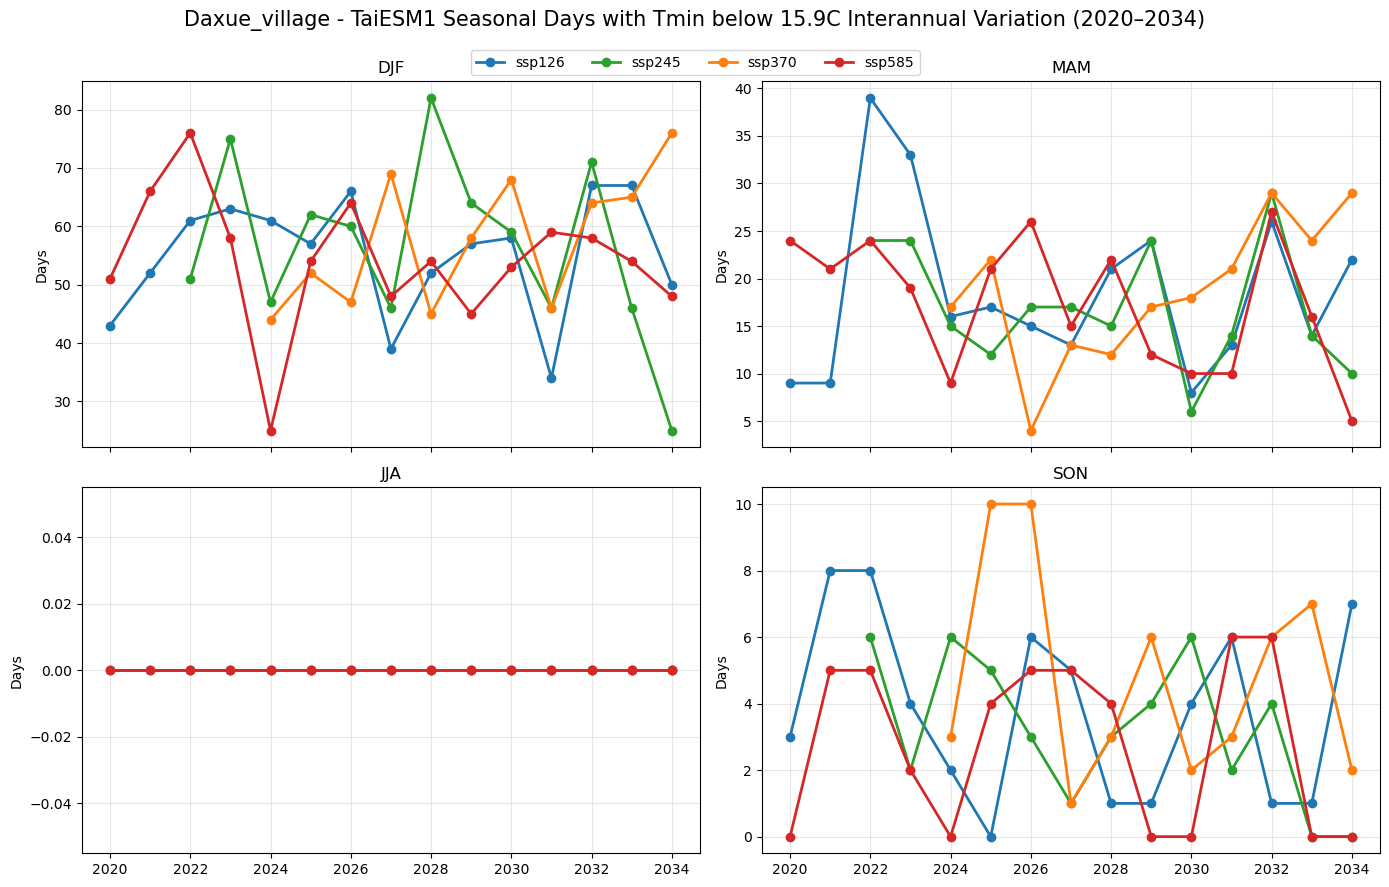

In [81]:
# 1. 季平均溫：看整體適生性
plot_seasonal_interannual_timeseries(
    seasonal_results, "tmean_seasonal_mean",
    "Seasonal Mean Tmean Interannual Variation", "°C",
    model_name, save_path
)

# 2. Tmax > 31°C：看最適生長窗口
plot_seasonal_interannual_timeseries(
    seasonal_results, "tmax_gt31_days",
    "Seasonal Days with Tmax over 31C Interannual Variation", "Days",
    model_name, save_path
)

# 3. Tmin < 15.9°C：看越冬屏障
plot_seasonal_interannual_timeseries(
    seasonal_results, "tmin_lt15_9_days",
    "Seasonal Days with Tmin below 15.9C Interannual Variation", "Days",
    model_name, save_path
)


plot_seasonal_interannual_timeseries(
    seasonal_results=seasonal_results,
    metric="tmax_gt31_days",
    title="Seasonal Days with Tmax over 31C Interannual Variation",
    ylabel="Days",
    model_name=model_name,
    save_path=save_path
)



plot_seasonal_interannual_timeseries(
    seasonal_results=seasonal_results,
    metric="tmax_ge35_days",
    title="Seasonal Days with Tmax gteo 35C Interannual Variation",
    ylabel="Days",
    model_name=model_name,
    save_path=save_path
)

plot_seasonal_interannual_timeseries(
    seasonal_results=seasonal_results,
    metric="tmin_lt15_9_days",
    title="Seasonal Days with Tmin below 15.9C Interannual Variation",
    ylabel="Days",
    model_name=model_name,
    save_path=save_path
)

[OK] ACCESS-CM2 | ssp126
     nearest grid = (25.0200, 121.5300)
     monthly rows = 264, seasonal rows = 90
[OK] ACCESS-CM2 | ssp245
     nearest grid = (25.0200, 121.5300)
     monthly rows = 252, seasonal rows = 86
[OK] ACCESS-CM2 | ssp370
     nearest grid = (25.0200, 121.5300)
     monthly rows = 264, seasonal rows = 90
[OK] ACCESS-CM2 | ssp585
     nearest grid = (25.0200, 121.5300)
     monthly rows = 288, seasonal rows = 98


C:\Users\user\AppData\Local\Temp\ipykernel_12628\259889971.py:319: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdf.groupby("season")
C:\Users\user\AppData\Local\Temp\ipykernel_12628\259889971.py:319: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdf.groupby("season")
C:\Users\user\AppData\Local\Temp\ipykernel_12628\259889971.py:319: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdf.groupby("season")
C:\Users\user\AppDa

✅ Saved: C:\Climate_project\程式作業\Daxue＿village\figue\Daxue_village_ACCESS-CM2_Seasonal_Cockroach_Thermal_Metrics_2010_2034.png


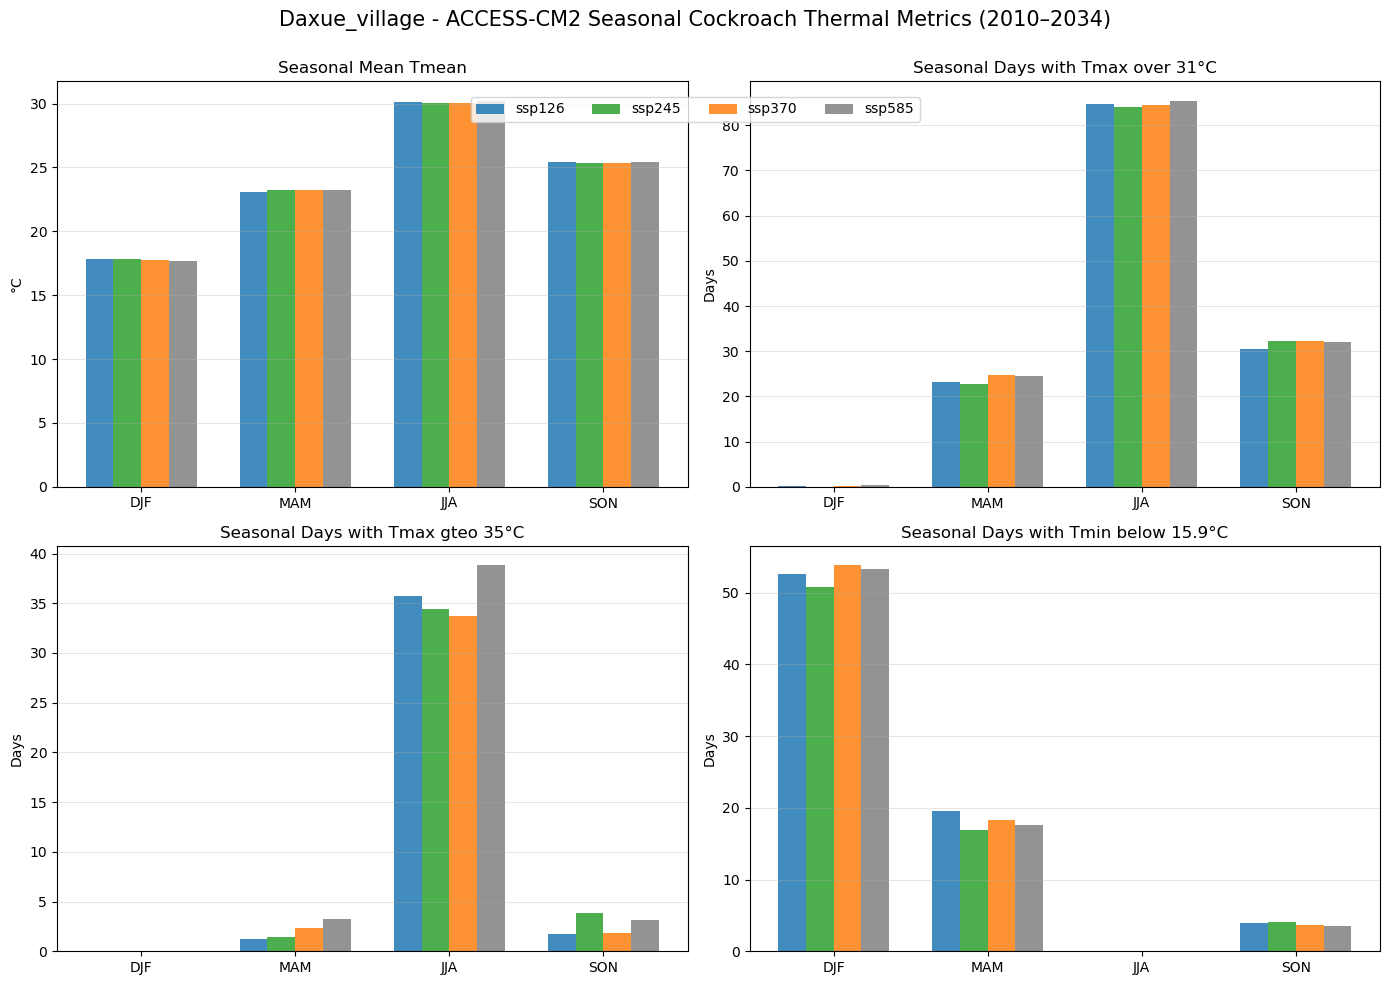

✅ Saved: C:\Climate_project\程式作業\Daxue＿village\figue\Daxue_village_ACCESS-CM2_Monthly_Cockroach_Thermal_Threshold_Days_2010_2034.png


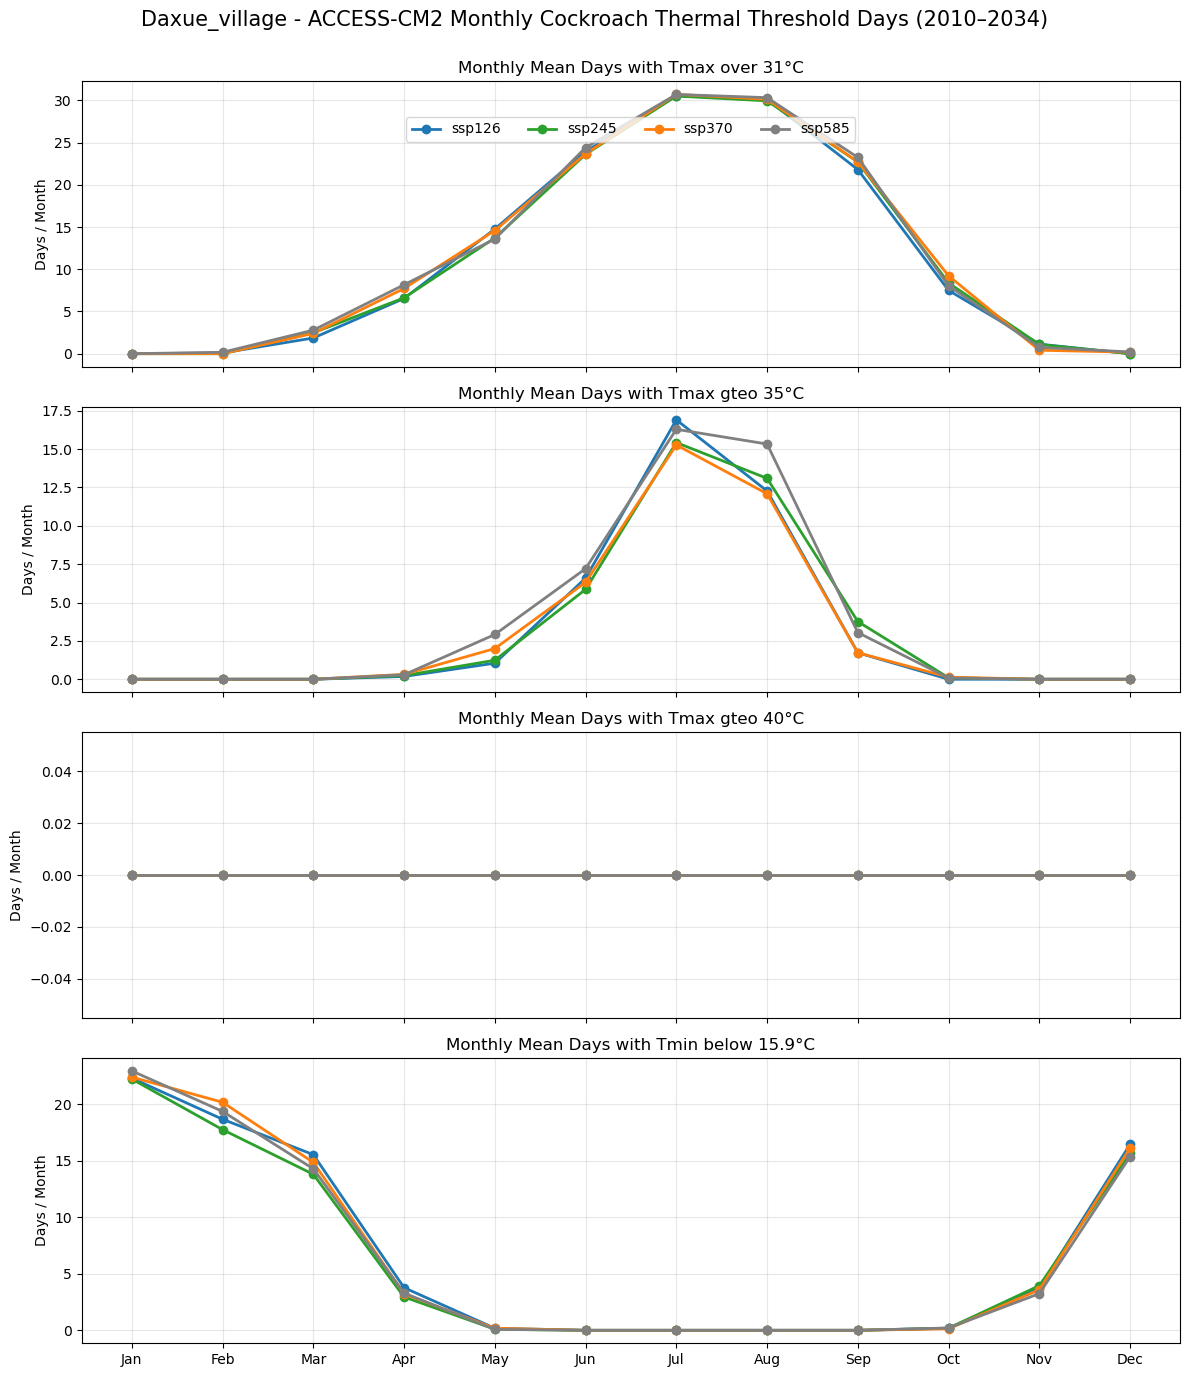

✅ Saved: C:\Climate_project\程式作業\Daxue＿village\figue\Daxue_village_ACCESS-CM2_Seasonal_Mean_Tmean_Interannual_Variation_2010_2034.png


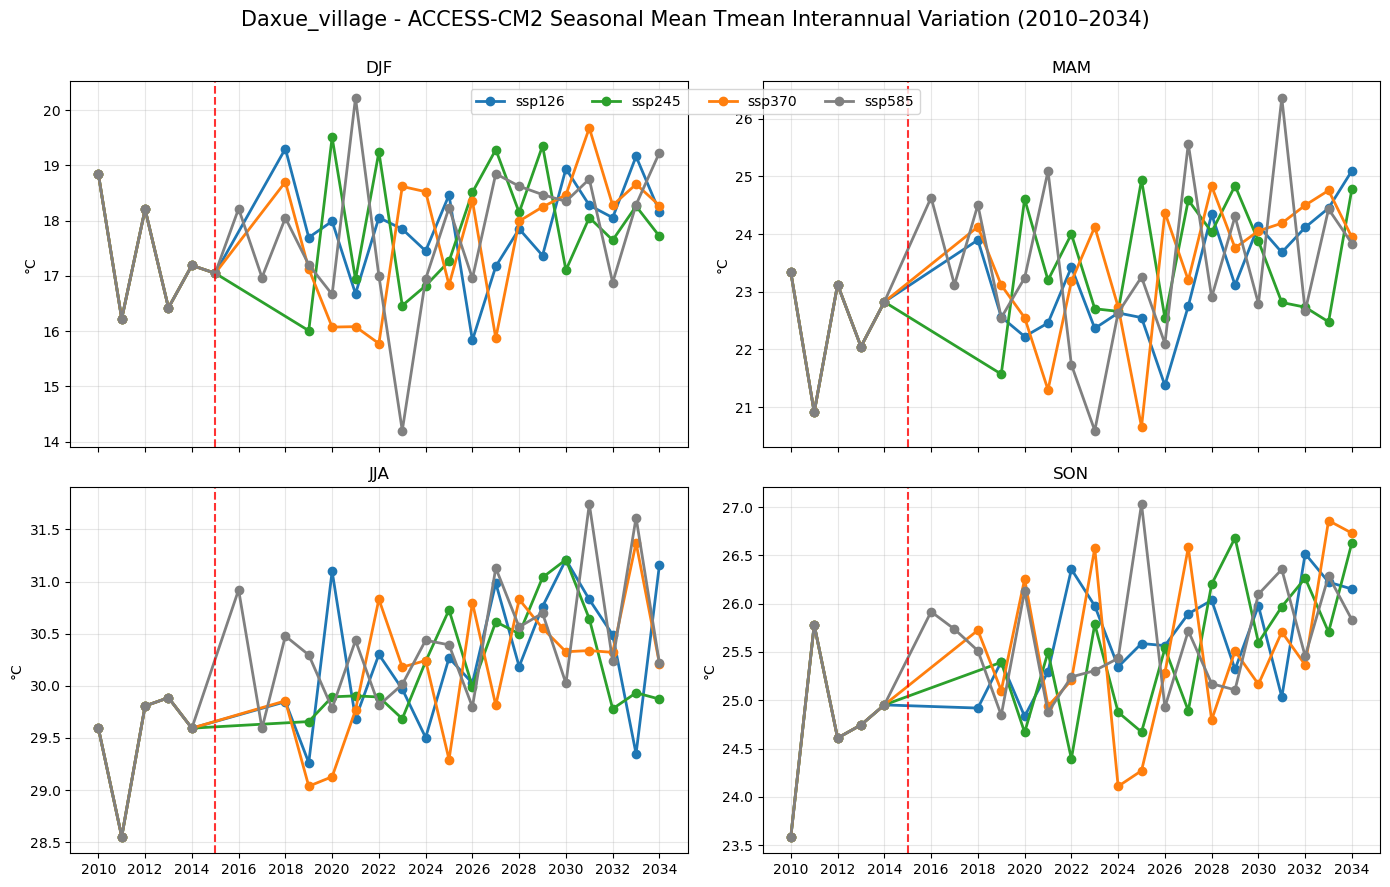

✅ Saved: C:\Climate_project\程式作業\Daxue＿village\figue\Daxue_village_ACCESS-CM2_Seasonal_Days_with_Tmax_over_31C_Interannual_Variation_2010_2034.png


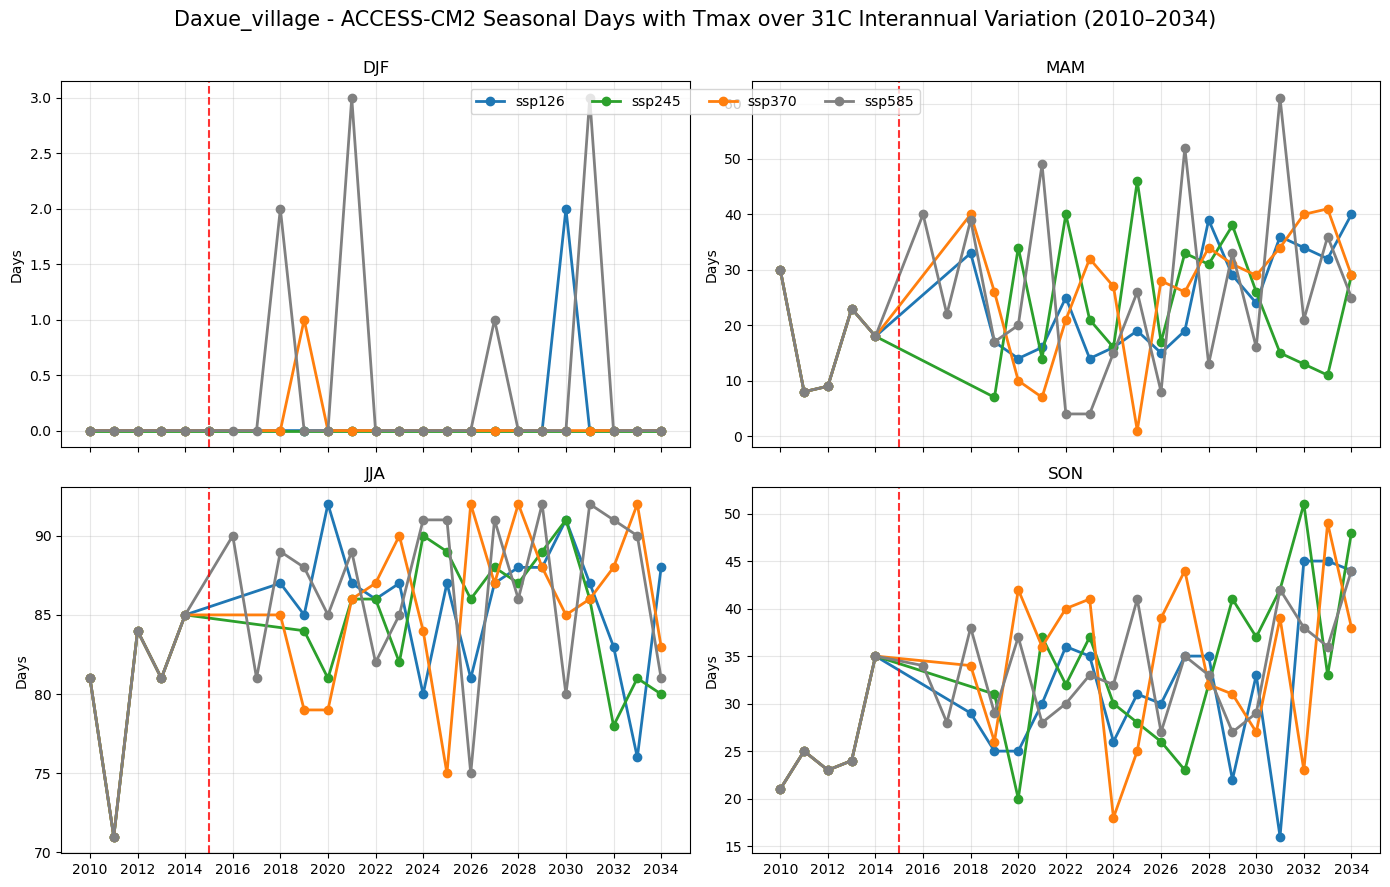

✅ Saved: C:\Climate_project\程式作業\Daxue＿village\figue\Daxue_village_ACCESS-CM2_Seasonal_Days_with_Tmin_below_15.9C_Interannual_Variation_2010_2034.png


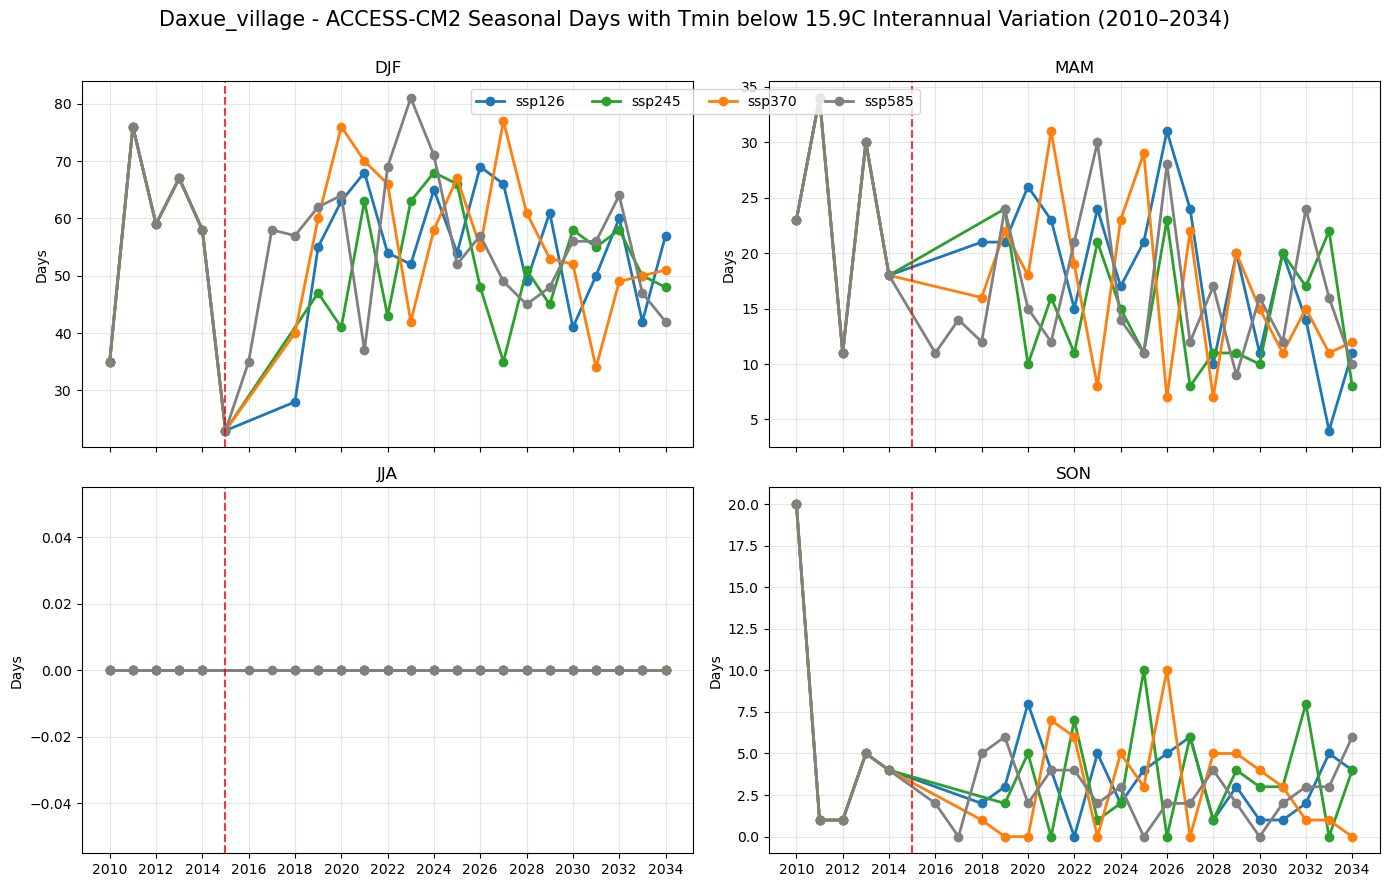

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# =========================================================
# 0. 基本設定
# =========================================================
poi_lat = 25.0190099143756
poi_lon = 121.53137177116402

# ===== 路徑設定（請依你的實際路徑修改）=====
# GWL1.5 資料夾
tmean_gwl_folder = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_平均溫\GWL1.5")
tmax_gwl_folder  = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最高溫\GWL1.5")
tmin_gwl_folder  = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最低溫\GWL1.5")

# historical 資料夾
tmean_hist_folder = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_平均溫\historical")
tmax_hist_folder  = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最高溫\historical")
tmin_hist_folder  = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最低溫\historical")

# 圖片輸出資料夾
save_path = Path(r"C:\Climate_project\程式作業\Daxue＿village\figue")  #"C:\Climate_project\程式作業\Daxue＿village\figue"
save_path.mkdir(parents=True, exist_ok=True)

# ===== 模式與情境 =====
model_name = "ACCESS-CM2"
target_ssps = ["ssp126", "ssp245", "ssp370", "ssp585"]

# ===== 時間範圍 =====
hist_start = "2010-01-01"
hist_end   = "2014-12-31"
fut_start  = "2015-01-01"
fut_end    = "2034-12-31"

start_year = 2010
end_year = 2034

INVALID_VALUE = -99.9

ssp_colors = {
    "ssp126": "#1f77b4",
    "ssp245": "#2ca02c",
    "ssp370": "#ff7f0e",
    "ssp585": "gray",
}

season_order = ["DJF", "MAM", "JJA", "SON"]


# =========================================================
# 1. 基本工具函式
# =========================================================
def read_csv_with_fallback(csv_path: Path):
    encodings = ["utf-8", "utf-8-sig", "big5"]
    last_error = None

    for enc in encodings:
        try:
            return pd.read_csv(csv_path, encoding=enc)
        except Exception as e:
            last_error = e

    raise last_error


def extract_year_from_filename(fp: Path):
    m = re.search(r"_(\d{4})\.csv$", fp.name)
    return int(m.group(1)) if m else -1


def get_historical_files(folder: Path, model_name: str):
    """
    historical 資料夾下抓某模式檔案
    """
    files = sorted(folder.glob("*.csv"))
    matched = [f for f in files if model_name in f.name]
    matched = sorted(matched, key=extract_year_from_filename)
    return matched


def get_gwl_ssp_files(folder: Path, model_name: str, ssp_name: str):
    """
    GWL1.5 資料夾下抓某模式 + 某 SSP 檔案
    """
    files = sorted(folder.glob("*.csv"))
    matched = [
        f for f in files
        if (model_name in f.name) and (ssp_name in f.name)
    ]
    matched = sorted(matched, key=extract_year_from_filename)
    return matched


def read_point_daily_series_from_csv(csv_path: Path, poi_lon: float, poi_lat: float):
    """
    適用 AR6 日資料格式：
    前兩欄為經緯度，後面欄位為 YYYYMMDD
    """
    df = read_csv_with_fallback(csv_path)

    cols_upper = [str(c).upper() for c in df.columns]
    df.columns = cols_upper

    lon_col = df.columns[0]
    lat_col = df.columns[1]

    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")

    # 找最近格點
    dist = np.sqrt((df[lon_col] - poi_lon) ** 2 + (df[lat_col] - poi_lat) ** 2)
    idx = dist.idxmin()
    row = df.loc[idx]

    date_cols = df.columns[2:]
    dates = pd.to_datetime(date_cols, format="%Y%m%d", errors="coerce")
    values = pd.to_numeric(row[date_cols], errors="coerce").replace(INVALID_VALUE, np.nan)

    s = pd.Series(values.values, index=dates)
    s = s[~s.index.isna()].sort_index()

    return s, float(row[lon_col]), float(row[lat_col])


def load_daily_series_from_files(files, poi_lon, poi_lat):
    if len(files) == 0:
        raise FileNotFoundError("找不到檔案")

    series_list = []
    nearest_lon = None
    nearest_lat = None

    for f in files:
        s, lon0, lat0 = read_point_daily_series_from_csv(f, poi_lon, poi_lat)
        series_list.append(s)
        nearest_lon = lon0
        nearest_lat = lat0

    full = pd.concat(series_list, axis=0)
    full = full[~full.index.duplicated(keep="first")]
    full = full.sort_index()

    return full, nearest_lon, nearest_lat


def load_historical_series(folder, model_name, poi_lon, poi_lat):
    files = get_historical_files(folder, model_name)
    return load_daily_series_from_files(files, poi_lon, poi_lat)


def load_gwl_ssp_series(folder, model_name, ssp_name, poi_lon, poi_lat):
    files = get_gwl_ssp_files(folder, model_name, ssp_name)
    return load_daily_series_from_files(files, poi_lon, poi_lat)


def combine_historical_and_ssp(hist_series, ssp_series):
    """
    historical: 2010–2014
    ssp: 2015–2034
    """
    hist_part = hist_series[hist_start:hist_end]
    ssp_part  = ssp_series[fut_start:fut_end]

    combined = pd.concat([hist_part, ssp_part])
    combined = combined.sort_index()
    combined = combined[~combined.index.duplicated(keep="first")]

    return combined


# =========================================================
# 2. 月統計與季統計
# =========================================================
def calc_monthly_stats(tmean_series, tmax_series, tmin_series):
    df = pd.DataFrame({
        "tmean": tmean_series,
        "tmax": tmax_series,
        "tmin": tmin_series
    }).dropna(how="all").sort_index()

    # 限制年份
    df = df[(df.index.year >= start_year) & (df.index.year <= end_year)].copy()

    df["year"] = df.index.year
    df["month"] = df.index.month
    df["ym"] = df.index.to_period("M")

    monthly = df.groupby("ym").agg(
        # 適生背景
        tmean_monthly_mean=("tmean", "mean"),

        # 高溫條件
        tmax_gt31_days=("tmax", lambda x: (x > 31).sum()),
        tmax_ge35_days=("tmax", lambda x: (x >= 35).sum()),
        tmax_ge40_days=("tmax", lambda x: (x >= 40).sum()),

        # 冷壓力
        tmin_lt15_9_days=("tmin", lambda x: (x < 15.9).sum()),

        n_days=("tmean", "count"),
    )

    monthly["year"] = monthly.index.year
    monthly["month"] = monthly.index.month

    return monthly.reset_index(drop=False)


def month_to_season(month):
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    else:
        return "SON"


def assign_season_year(year, month):
    if month == 12:
        return year + 1
    return year


def calc_seasonal_stats_from_monthly(monthly_df):
    df = monthly_df.copy()

    df["season"] = df["month"].apply(month_to_season)
    df["season_year"] = df.apply(
        lambda r: assign_season_year(int(r["year"]), int(r["month"])),
        axis=1
    )

    seasonal = df.groupby(["season_year", "season"]).agg(
        tmean_seasonal_mean=("tmean_monthly_mean", "mean"),
        tmax_gt31_days=("tmax_gt31_days", "sum"),
        tmax_ge35_days=("tmax_ge35_days", "sum"),
        tmax_ge40_days=("tmax_ge40_days", "sum"),
        tmin_lt15_9_days=("tmin_lt15_9_days", "sum"),
        n_days=("n_days", "sum"),
    ).reset_index()

    seasonal["season"] = pd.Categorical(seasonal["season"], categories=season_order, ordered=True)
    seasonal = seasonal.sort_values(["season_year", "season"])

    return seasonal


# =========================================================
# 3. 主流程：同一模式，不同 SSP
# =========================================================
monthly_results = {}
seasonal_results = {}
grid_info = {}

for ssp in target_ssps:
    try:
        # ===== historical =====
        hist_tmean, lon0, lat0 = load_historical_series(
            tmean_hist_folder, model_name, poi_lon, poi_lat
        )
        hist_tmax, _, _ = load_historical_series(
            tmax_hist_folder, model_name, poi_lon, poi_lat
        )
        hist_tmin, _, _ = load_historical_series(
            tmin_hist_folder, model_name, poi_lon, poi_lat
        )

        # ===== SSP from GWL1.5 =====
        ssp_tmean, _, _ = load_gwl_ssp_series(
            tmean_gwl_folder, model_name, ssp, poi_lon, poi_lat
        )
        ssp_tmax, _, _ = load_gwl_ssp_series(
            tmax_gwl_folder, model_name, ssp, poi_lon, poi_lat
        )
        ssp_tmin, _, _ = load_gwl_ssp_series(
            tmin_gwl_folder, model_name, ssp, poi_lon, poi_lat
        )

        # ===== combine =====
        tmean_series = combine_historical_and_ssp(hist_tmean, ssp_tmean)
        tmax_series  = combine_historical_and_ssp(hist_tmax,  ssp_tmax)
        tmin_series  = combine_historical_and_ssp(hist_tmin,  ssp_tmin)

        monthly_df = calc_monthly_stats(tmean_series, tmax_series, tmin_series)
        seasonal_df = calc_seasonal_stats_from_monthly(monthly_df)

        monthly_results[ssp] = monthly_df
        seasonal_results[ssp] = seasonal_df
        grid_info[ssp] = {"lon": lon0, "lat": lat0}

        print(f"[OK] {model_name} | {ssp}")
        print(f"     nearest grid = ({lat0:.4f}, {lon0:.4f})")
        print(f"     monthly rows = {len(monthly_df)}, seasonal rows = {len(seasonal_df)}")

    except Exception as e:
        print(f"[SKIP] {model_name} | {ssp}: {e}")


# =========================================================
# 4. 季節摘要表
# =========================================================
def build_seasonal_summary_table(seasonal_results, ssp_order=None, season_order=None):
    if ssp_order is None:
        ssp_order = sorted(seasonal_results.keys())
    if season_order is None:
        season_order = ["DJF", "MAM", "JJA", "SON"]

    summary = {}

    for ssp in ssp_order:
        sdf = seasonal_results[ssp].copy()

        tmp = (
            sdf.groupby("season")
            .agg(
                tmean_seasonal_mean=("tmean_seasonal_mean", "mean"),
                tmax_gt31_days=("tmax_gt31_days", "mean"),
                tmax_ge35_days=("tmax_ge35_days", "mean"),
                tmax_ge40_days=("tmax_ge40_days", "mean"),
                tmin_lt15_9_days=("tmin_lt15_9_days", "mean"),
            )
            .reindex(season_order)
        )

        summary[ssp] = tmp

    return summary


# =========================================================
# 5. 圖 1：季節長條圖
# =========================================================
def safe_filename(text):
    return (
        text.replace(" ", "_")
            .replace(">", "gt")
            .replace("<", "lt")
            .replace("=", "eq")
            .replace("°", "")
            .replace("/", "_")
    )


def plot_seasonal_bar_charts(seasonal_results, model_name, save_path=None):
    seasonal_summary = build_seasonal_summary_table(
        seasonal_results,
        ssp_order=target_ssps,
        season_order=season_order
    )

    metrics = [
        ("tmean_seasonal_mean", "Seasonal Mean Tmean", "°C"),
        ("tmax_gt31_days", "Seasonal Days with Tmax over 31°C", "Days"),
        ("tmax_ge35_days", "Seasonal Days with Tmax gteo 35°C", "Days"),
        ("tmin_lt15_9_days", "Seasonal Days with Tmin below 15.9°C", "Days"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    x = np.arange(len(season_order))
    width = 0.18

    for ax, (metric, title, ylabel) in zip(axes, metrics):
        for i, ssp in enumerate(target_ssps):
            vals = seasonal_summary[ssp][metric].values
            ax.bar(
                x + (i - 1.5) * width,
                vals,
                width=width,
                label=ssp,
                color=ssp_colors.get(ssp, None),
                alpha=0.85
            )

        ax.set_xticks(x)
        ax.set_xticklabels(season_order)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(axis="y", alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4,bbox_to_anchor=(0.5, 0.90))
    fig.suptitle(f"Daxue_village - {model_name} Seasonal Cockroach Thermal Metrics (2010–2034)", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        filename = f"Daxue_village_{model_name}_{safe_filename('Seasonal Cockroach Thermal Metrics')}_2010_2034.png"
        save_file = save_path / filename
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()


# =========================================================
# 6. 圖 2：每月閾值折線圖
# =========================================================
def build_monthly_threshold_climatology(monthly_results, ssp_order=None):
    if ssp_order is None:
        ssp_order = sorted(monthly_results.keys())

    climatology = {}

    for ssp in ssp_order:
        mdf = monthly_results[ssp].copy()

        tmp = (
            mdf.groupby("month")
            .agg(
                tmax_gt31_days=("tmax_gt31_days", "mean"),
                tmax_ge35_days=("tmax_ge35_days", "mean"),
                tmax_ge40_days=("tmax_ge40_days", "mean"),
                tmin_lt15_9_days=("tmin_lt15_9_days", "mean"),
            )
            .reindex(range(1, 13))
        )

        climatology[ssp] = tmp

    return climatology


def plot_monthly_threshold_lines(monthly_results, model_name, save_path=None):
    monthly_clim = build_monthly_threshold_climatology(
        monthly_results,
        ssp_order=target_ssps
    )

    metrics = [
        ("tmax_gt31_days", "Monthly Mean Days with Tmax over 31°C", "Days / Month"),
        ("tmax_ge35_days", "Monthly Mean Days with Tmax gteo 35°C", "Days / Month"),
        ("tmax_ge40_days", "Monthly Mean Days with Tmax gteo 40°C", "Days / Month"),
        ("tmin_lt15_9_days", "Monthly Mean Days with Tmin below 15.9°C", "Days / Month"),
    ]

    month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

    for ax, (metric, title, ylabel) in zip(axes, metrics):
        for ssp in target_ssps:
            vals = monthly_clim[ssp][metric].values

            ax.plot(
                range(1, 13),
                vals,
                marker="o",
                linewidth=2,
                label=ssp,
                color=ssp_colors.get(ssp, None)
            )

        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

    axes[-1].set_xticks(range(1, 13))
    axes[-1].set_xticklabels(month_labels)
    axes[0].legend(ncol=4, loc="upper center",bbox_to_anchor=(0.5, 0.90))

    fig.suptitle(f"Daxue_village - {model_name} Monthly Cockroach Thermal Threshold Days (2010–2034)", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        filename = f"Daxue_village_{model_name}_{safe_filename('Monthly Cockroach Thermal Threshold Days')}_2010_2034.png"
        save_file = save_path / filename
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()


# =========================================================
# 7. 圖 3：各季節逐年變化圖
# =========================================================
def plot_seasonal_interannual_timeseries(
    seasonal_results,
    metric,
    title,
    ylabel,
    model_name,
    save_path=None,
    ylim=None
):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    axes = axes.flatten()

    for i, season in enumerate(season_order):
        ax = axes[i]

        for ssp in target_ssps:
            if ssp not in seasonal_results:
                continue

            sdf = seasonal_results[ssp].copy()
            sub = sdf[sdf["season"] == season].copy()
            sub = sub[(sub["season_year"] >= start_year) & (sub["season_year"] <= end_year)]

            if len(sub) == 0:
                continue

            ax.plot(
                sub["season_year"],
                sub[metric],
                marker="o",
                linewidth=2,
                label=ssp,
                color=ssp_colors.get(ssp, None)
            )

        ax.axvline(x=2015, color="red", linestyle="--", linewidth=1.5, alpha=0.8)
        ax.set_title(season)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

        if ylim is not None:
            ax.set_ylim(ylim)

        xticks = np.arange(start_year, end_year + 1, 2)
        ax.set_xticks(xticks)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4,bbox_to_anchor=(0.5, 0.90))
    fig.suptitle(f"Daxue_village - {model_name} {title} (2010–2034)", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        filename = f"Daxue_village_{model_name}_{safe_filename(title)}_2010_2034.png"
        save_file = save_path / filename
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()

In [ ]:
# =========================================================
# 8. 執行畫圖
# =========================================================
plot_seasonal_bar_charts(
    seasonal_results=seasonal_results,
    model_name=model_name,
    save_path=save_path
)

plot_monthly_threshold_lines(
    monthly_results=monthly_results,
    model_name=model_name,
    save_path=save_path
)

# 各季節逐年變化圖：你最重要的三張
plot_seasonal_interannual_timeseries(
    seasonal_results=seasonal_results,
    metric="tmean_seasonal_mean",
    title="Seasonal Mean Tmean Interannual Variation",
    ylabel="°C",
    model_name=model_name,
    save_path=save_path
)

plot_seasonal_interannual_timeseries(
    seasonal_results=seasonal_results,
    metric="tmax_gt31_days",
    title="Seasonal Days with Tmax over 31C Interannual Variation",
    ylabel="Days",
    model_name=model_name,
    save_path=save_path
)

plot_seasonal_interannual_timeseries(
    seasonal_results=seasonal_results,
    metric="tmin_lt15_9_days",
    title="Seasonal Days with Tmin below 15.9C Interannual Variation",
    ylabel="Days",
    model_name=model_name,
    save_path=save_path
)

In [14]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# =========================================================
# 0. 基本設定
# =========================================================
poi_lat = 25.0190099143756
poi_lon = 121.53137177116402

# ===== 路徑 =====
tmean_gwl_folder = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_平均溫\GWL1.5")
tmax_gwl_folder  = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最高溫\GWL1.5")
tmin_gwl_folder  = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最低溫\GWL1.5")

tmean_hist_folder = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_平均溫\historical")
tmax_hist_folder  = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最高溫\historical")
tmin_hist_folder  = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最低溫\historical")

save_path = Path(r"C:\Climate_project\程式作業\Daxue＿village\figue")
save_path.mkdir(parents=True, exist_ok=True)

# ===== 模式與情境 =====
model_name = "ACCESS-CM2" # ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]
target_ssps = ["ssp245", "ssp370", "ssp585"]

# ===== 時間範圍 =====
hist_start = "2004-01-01"
hist_end   = "2014-12-31"
fut_start  = "2015-01-01"
fut_end    = "2034-12-31"

start_year = 2004
end_year = 2034

INVALID_VALUE = -99.9

ssp_colors = {
    "ssp245": "#2ca02c",  # green
    "ssp370": "blue",  # orange
    "ssp585": "#d62728",  # red
}

season_order = ["DJF", "MAM", "JJA", "SON"]


# =========================================================
# 1. 基本工具
# =========================================================
def safe_filename(text):
    return (
        text.replace(" ", "_")
            .replace(">", "gt")
            .replace("<", "lt")
            .replace("=", "eq")
            .replace("°", "")
            .replace("/", "_")
    )


def read_csv_with_fallback(csv_path: Path):
    encodings = ["utf-8", "utf-8-sig", "big5"]
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(csv_path, encoding=enc)
        except Exception as e:
            last_error = e
    raise last_error


def extract_year_from_filename(fp: Path):
    m = re.search(r"_(\d{4})\.csv$", fp.name)
    return int(m.group(1)) if m else -1


def get_historical_files(folder: Path, model_name: str):
    files = sorted(folder.glob("*.csv"))
    matched = [f for f in files if model_name in f.name]
    return sorted(matched, key=extract_year_from_filename)


def get_gwl_ssp_files(folder: Path, model_name: str, ssp_name: str):
    files = sorted(folder.glob("*.csv"))
    matched = [f for f in files if (model_name in f.name) and (ssp_name in f.name)]
    return sorted(matched, key=extract_year_from_filename)


def read_point_daily_series_from_csv(csv_path: Path, poi_lon: float, poi_lat: float):
    """
    格式：
    前兩欄：經緯度
    後面欄位：YYYYMMDD
    """
    df = read_csv_with_fallback(csv_path)

    cols_upper = [str(c).upper() for c in df.columns]
    df.columns = cols_upper

    lon_col = df.columns[0]
    lat_col = df.columns[1]

    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")

    dist = np.sqrt((df[lon_col] - poi_lon) ** 2 + (df[lat_col] - poi_lat) ** 2)
    idx = dist.idxmin()
    row = df.loc[idx]

    date_cols = df.columns[2:]
    dates = pd.to_datetime(date_cols, format="%Y%m%d", errors="coerce")
    values = pd.to_numeric(row[date_cols], errors="coerce").replace(INVALID_VALUE, np.nan)

    s = pd.Series(values.values, index=dates)
    s = s[~s.index.isna()].sort_index()

    return s, float(row[lon_col]), float(row[lat_col])


def load_daily_series_from_files(files, poi_lon, poi_lat):
    if len(files) == 0:
        raise FileNotFoundError("找不到檔案")

    series_list = []
    nearest_lon = None
    nearest_lat = None

    for f in files:
        s, lon0, lat0 = read_point_daily_series_from_csv(f, poi_lon, poi_lat)
        series_list.append(s)
        nearest_lon = lon0
        nearest_lat = lat0

    full = pd.concat(series_list, axis=0)
    full = full[~full.index.duplicated(keep="first")]
    full = full.sort_index()

    return full, nearest_lon, nearest_lat


def load_historical_series(folder, model_name, poi_lon, poi_lat):
    files = get_historical_files(folder, model_name)
    return load_daily_series_from_files(files, poi_lon, poi_lat)


def load_gwl_ssp_series(folder, model_name, ssp_name, poi_lon, poi_lat):
    files = get_gwl_ssp_files(folder, model_name, ssp_name)
    return load_daily_series_from_files(files, poi_lon, poi_lat)


def combine_historical_and_ssp(hist_series, ssp_series):
    hist_part = hist_series[hist_start:hist_end]
    ssp_part  = ssp_series[fut_start:fut_end]

    combined = pd.concat([hist_part, ssp_part])
    combined = combined.sort_index()
    combined = combined[~combined.index.duplicated(keep="first")]

    return combined


def calc_trend_line(x, y):
    """
    x: 年份 array
    y: 數值 array
    回傳 slope, intercept, fitted_y
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return np.nan, np.nan, np.full_like(x, np.nan, dtype=float)

    slope, intercept = np.polyfit(x, y, 1)
    fitted = slope * x + intercept
    return slope, intercept, fitted


# =========================================================
# 2. 月統計與季統計
# =========================================================
def calc_monthly_stats(tmean_series, tmax_series, tmin_series):
    df = pd.DataFrame({
        "tmean": tmean_series,
        "tmax": tmax_series,
        "tmin": tmin_series
    }).dropna(how="all").sort_index()

    df = df[(df.index.year >= start_year) & (df.index.year <= end_year)].copy()

    df["year"] = df.index.year
    df["month"] = df.index.month
    df["ym"] = df.index.to_period("M")

    monthly = df.groupby("ym").agg(
        tmean_monthly_mean=("tmean", "mean"),
        tmax_gt31_days=("tmax", lambda x: (x > 31).sum()),
        tmax_ge35_days=("tmax", lambda x: (x >= 35).sum()),
        tmax_ge40_days=("tmax", lambda x: (x >= 40).sum()),
        tmin_lt15_9_days=("tmin", lambda x: (x < 15.9).sum()),
        n_days=("tmean", "count"),
    )

    monthly["year"] = monthly.index.year
    monthly["month"] = monthly.index.month
    return monthly.reset_index(drop=False)


def month_to_season(month):
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    else:
        return "SON"


def assign_season_year(year, month):
    if month == 12:
        return year + 1
    return year


def calc_seasonal_stats_from_monthly(monthly_df):
    df = monthly_df.copy()
    df["season"] = df["month"].apply(month_to_season)
    df["season_year"] = df.apply(lambda r: assign_season_year(int(r["year"]), int(r["month"])), axis=1)

    seasonal = df.groupby(["season_year", "season"]).agg(
        tmean_seasonal_mean=("tmean_monthly_mean", "mean"),
        tmax_gt31_days=("tmax_gt31_days", "sum"),
        tmax_ge35_days=("tmax_ge35_days", "sum"),
        tmax_ge40_days=("tmax_ge40_days", "sum"),
        tmin_lt15_9_days=("tmin_lt15_9_days", "sum"),
        n_days=("n_days", "sum"),
    ).reset_index()

    seasonal["season"] = pd.Categorical(seasonal["season"], categories=season_order, ordered=True)
    seasonal = seasonal.sort_values(["season_year", "season"])

    return seasonal


# =========================================================
# 3. 主流程：單一模式、不同 SSP
# =========================================================
monthly_results = {}
seasonal_results = {}
grid_info = {}

for ssp in target_ssps:
    try:
        hist_tmean, lon0, lat0 = load_historical_series(tmean_hist_folder, model_name, poi_lon, poi_lat)
        hist_tmax, _, _ = load_historical_series(tmax_hist_folder, model_name, poi_lon, poi_lat)
        hist_tmin, _, _ = load_historical_series(tmin_hist_folder, model_name, poi_lon, poi_lat)

        ssp_tmean, _, _ = load_gwl_ssp_series(tmean_gwl_folder, model_name, ssp, poi_lon, poi_lat)
        ssp_tmax, _, _ = load_gwl_ssp_series(tmax_gwl_folder, model_name, ssp, poi_lon, poi_lat)
        ssp_tmin, _, _ = load_gwl_ssp_series(tmin_gwl_folder, model_name, ssp, poi_lon, poi_lat)

        tmean_series = combine_historical_and_ssp(hist_tmean, ssp_tmean)
        tmax_series  = combine_historical_and_ssp(hist_tmax,  ssp_tmax)
        tmin_series  = combine_historical_and_ssp(hist_tmin,  ssp_tmin)

        monthly_df = calc_monthly_stats(tmean_series, tmax_series, tmin_series)
        seasonal_df = calc_seasonal_stats_from_monthly(monthly_df)

        monthly_results[ssp] = monthly_df
        seasonal_results[ssp] = seasonal_df
        grid_info[ssp] = {"lon": lon0, "lat": lat0}

        print(f"[OK] {model_name} | {ssp}")
        print(f"     nearest grid = ({lat0:.4f}, {lon0:.4f})")
        print(f"     monthly rows = {len(monthly_df)}, seasonal rows = {len(seasonal_df)}")

    except Exception as e:
        print(f"[SKIP] {model_name} | {ssp}: {e}")


# =========================================================
# 4. 季節摘要表
# =========================================================
def build_seasonal_summary_table(seasonal_results, ssp_order=None, season_order=None):
    if ssp_order is None:
        ssp_order = sorted(seasonal_results.keys())
    if season_order is None:
        season_order = ["DJF", "MAM", "JJA", "SON"]

    summary = {}

    for ssp in ssp_order:
        sdf = seasonal_results[ssp].copy()
        tmp = (
            sdf.groupby("season")
            .agg(
                tmean_seasonal_mean=("tmean_seasonal_mean", "mean"),
                tmax_gt31_days=("tmax_gt31_days", "mean"),
                tmax_ge35_days=("tmax_ge35_days", "mean"),
                tmax_ge40_days=("tmax_ge40_days", "mean"),
                tmin_lt15_9_days=("tmin_lt15_9_days", "mean"),
            )
            .reindex(season_order)
        )
        summary[ssp] = tmp

    return summary


# =========================================================
# 5. 圖 1：季節長條圖
# =========================================================
def plot_seasonal_bar_charts(seasonal_results, model_name, save_path=None):
    seasonal_summary = build_seasonal_summary_table(
        seasonal_results,
        ssp_order=target_ssps,
        season_order=season_order
    )

    metrics = [
        ("tmean_seasonal_mean", "Seasonal Mean Tmean", "°C"),
        ("tmax_gt31_days", "Seasonal Days with Tmax > 31°C", "Days"),
        ("tmax_ge35_days", "Seasonal Days with Tmax ≥ 35°C", "Days"),
        ("tmin_lt15_9_days", "Seasonal Days with Tmin < 15.9°C", "Days"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    x = np.arange(len(season_order))
    width = 0.24

    for ax, (metric, title, ylabel) in zip(axes, metrics):
        for i, ssp in enumerate(target_ssps):
            vals = seasonal_summary[ssp][metric].values
            ax.bar(
                x + (i - 1) * width,
                vals,
                width=width,
                label=ssp,
                color=ssp_colors.get(ssp),
                alpha=0.85
            )

        ax.set_xticks(x)
        ax.set_xticklabels(season_order)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(axis="y", alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3,bbox_to_anchor=(0.5, 0.95))
    fig.suptitle(f"Daxue_village - {model_name} Seasonal Cockroach Thermal Metrics (2015–2034)", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        filename = f"Daxue_village_{model_name}_{safe_filename('Seasonal Cockroach Thermal Metrics')}_2015_2034.png"
        save_file = save_path / filename
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()


# =========================================================
# 6. 圖 2：每月閾值折線圖
# =========================================================
def build_monthly_threshold_climatology(monthly_results, ssp_order=None):
    if ssp_order is None:
        ssp_order = sorted(monthly_results.keys())

    climatology = {}
    for ssp in ssp_order:
        mdf = monthly_results[ssp].copy()
        tmp = (
            mdf.groupby("month")
            .agg(
                tmax_gt31_days=("tmax_gt31_days", "mean"),
                tmax_ge35_days=("tmax_ge35_days", "mean"),
                tmax_ge40_days=("tmax_ge40_days", "mean"),
                tmin_lt15_9_days=("tmin_lt15_9_days", "mean"),
            )
            .reindex(range(1, 13))
        )
        climatology[ssp] = tmp

    return climatology


def plot_monthly_threshold_lines(monthly_results, model_name, save_path=None):
    monthly_clim = build_monthly_threshold_climatology(monthly_results, ssp_order=target_ssps)

    metrics = [
        ("tmax_gt31_days", "Monthly Mean Days with Tmax > 31°C", "Days / Month"),
        ("tmax_ge35_days", "Monthly Mean Days with Tmax ≥ 35°C", "Days / Month"),
        ("tmax_ge40_days", "Monthly Mean Days with Tmax ≥ 40°C", "Days / Month"),
        ("tmin_lt15_9_days", "Monthly Mean Days with Tmin < 15.9°C", "Days / Month"),
    ]

    month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

    for ax, (metric, title, ylabel) in zip(axes, metrics):
        for ssp in target_ssps:
            vals = monthly_clim[ssp][metric].values
            ax.plot(
                range(1, 13),
                vals,
                marker="o",
                linewidth=2,
                label=ssp,
                color=ssp_colors.get(ssp)
            )

        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

    axes[-1].set_xticks(range(1, 13))
    axes[-1].set_xticklabels(month_labels)
    axes[0].legend(ncol=3, loc="upper center")

    fig.suptitle(f"Daxue_village - {model_name} Monthly Cockroach Thermal Threshold Days (2015–2034)", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        filename = f"Daxue_village_{model_name}_{safe_filename('Monthly Cockroach Thermal Threshold Days')}_2015_2034.png"
        save_file = save_path / filename
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()


# =========================================================
# 7. 圖 3：各季節逐年變化圖（historical 與 future 分開畫）
# =========================================================
def plot_seasonal_interannual_timeseries(
    seasonal_results,
    metric,
    title,
    ylabel,
    model_name,
    save_path=None,
    ylim=None,
   
):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    axes = axes.flatten()

    for i, season in enumerate(season_order):
        ax = axes[i]

        historical_drawn = False

        for ssp in target_ssps:
            if ssp not in seasonal_results:
                continue

            sdf = seasonal_results[ssp].copy()
            sub = sdf[sdf["season"] == season].copy()
            sub = sub[(sub["season_year"] >= start_year) & (sub["season_year"] <= end_year)]

            if len(sub) == 0:
                continue

            hist_part = sub[sub["season_year"] <= 2014]
            fut_part  = sub[sub["season_year"] >= 2015]

            # historical：只畫一次灰色
            if len(hist_part) > 0 and not historical_drawn:
                ax.plot(
                    hist_part["season_year"],
                    hist_part[metric],
                    color="gray",
                    linewidth=1.8,
                    alpha=0.8,
                    label="historical"
                )
                historical_drawn = True

            # future：各 SSP 彩色
            if len(fut_part) > 0:
                ax.plot(
                    fut_part["season_year"],
                    fut_part[metric],
                    marker="o",
                    linewidth=2,
                    color=ssp_colors.get(ssp),
                    label=ssp
                )

            # 分界線
            ax.axvline(x=2015, color="red", linestyle="--", linewidth=1.5, alpha=0.8)

        ax.set_title(season)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

        if ylim is not None:
            ax.set_ylim(ylim)

        xticks = np.arange(start_year, end_year + 1, 2)
        ax.set_xticks(xticks)

    handles, labels = axes[0].get_legend_handles_labels()

    # 去重 legend
    uniq = dict(zip(labels, handles))
    fig.legend(uniq.values(), uniq.keys(), loc="upper center", ncol=4,bbox_to_anchor=(0.5, 0.95))

    fig.suptitle(f"Daxue_village - {model_name} {title} (2004–2034)", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        filename = f"Daxue_village_{model_name}_{safe_filename(title)}_2004_2034.png"
        save_file = save_path / filename
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()


[OK] ACCESS-CM2 | ssp245
     nearest grid = (25.0200, 121.5300)
     monthly rows = 324, seasonal rows = 110
[OK] ACCESS-CM2 | ssp370
     nearest grid = (25.0200, 121.5300)
     monthly rows = 336, seasonal rows = 114
[OK] ACCESS-CM2 | ssp585
     nearest grid = (25.0200, 121.5300)
     monthly rows = 360, seasonal rows = 122


C:\Users\user\AppData\Local\Temp\ipykernel_18184\1440335423.py:302: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdf.groupby("season")
C:\Users\user\AppData\Local\Temp\ipykernel_18184\1440335423.py:302: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdf.groupby("season")
C:\Users\user\AppData\Local\Temp\ipykernel_18184\1440335423.py:302: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdf.groupby("season")


✅ Saved: C:\Climate_project\程式作業\Daxue＿village\figue\Daxue_village_TaiESM1_Seasonal_Cockroach_Thermal_Metrics_2015_2034.png


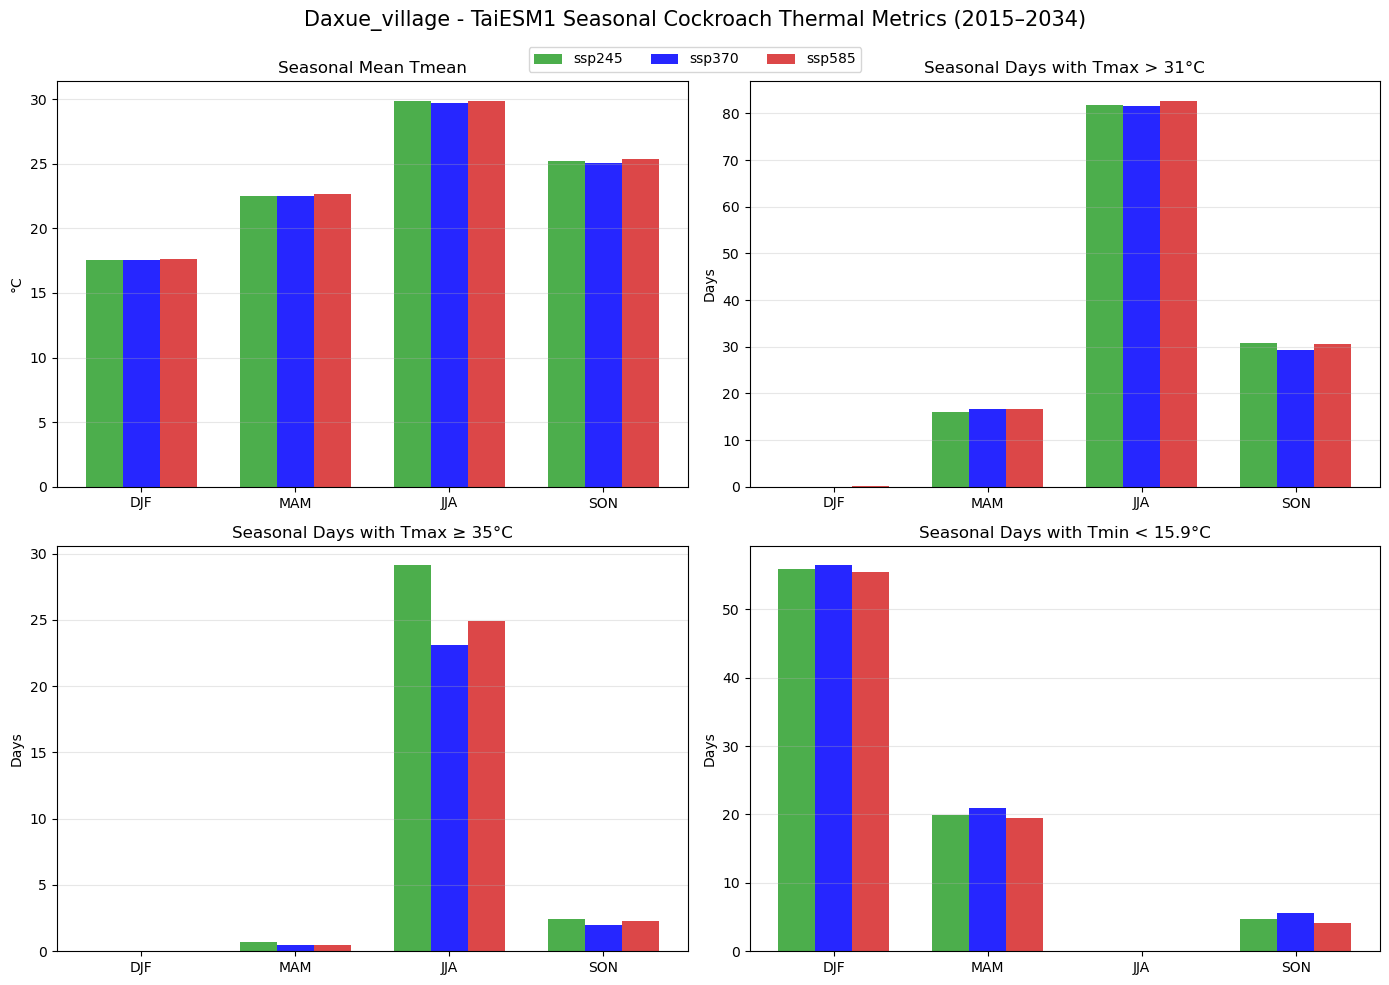

✅ Saved: C:\Climate_project\程式作業\Daxue＿village\figue\Daxue_village_TaiESM1_Monthly_Cockroach_Thermal_Threshold_Days_2015_2034.png


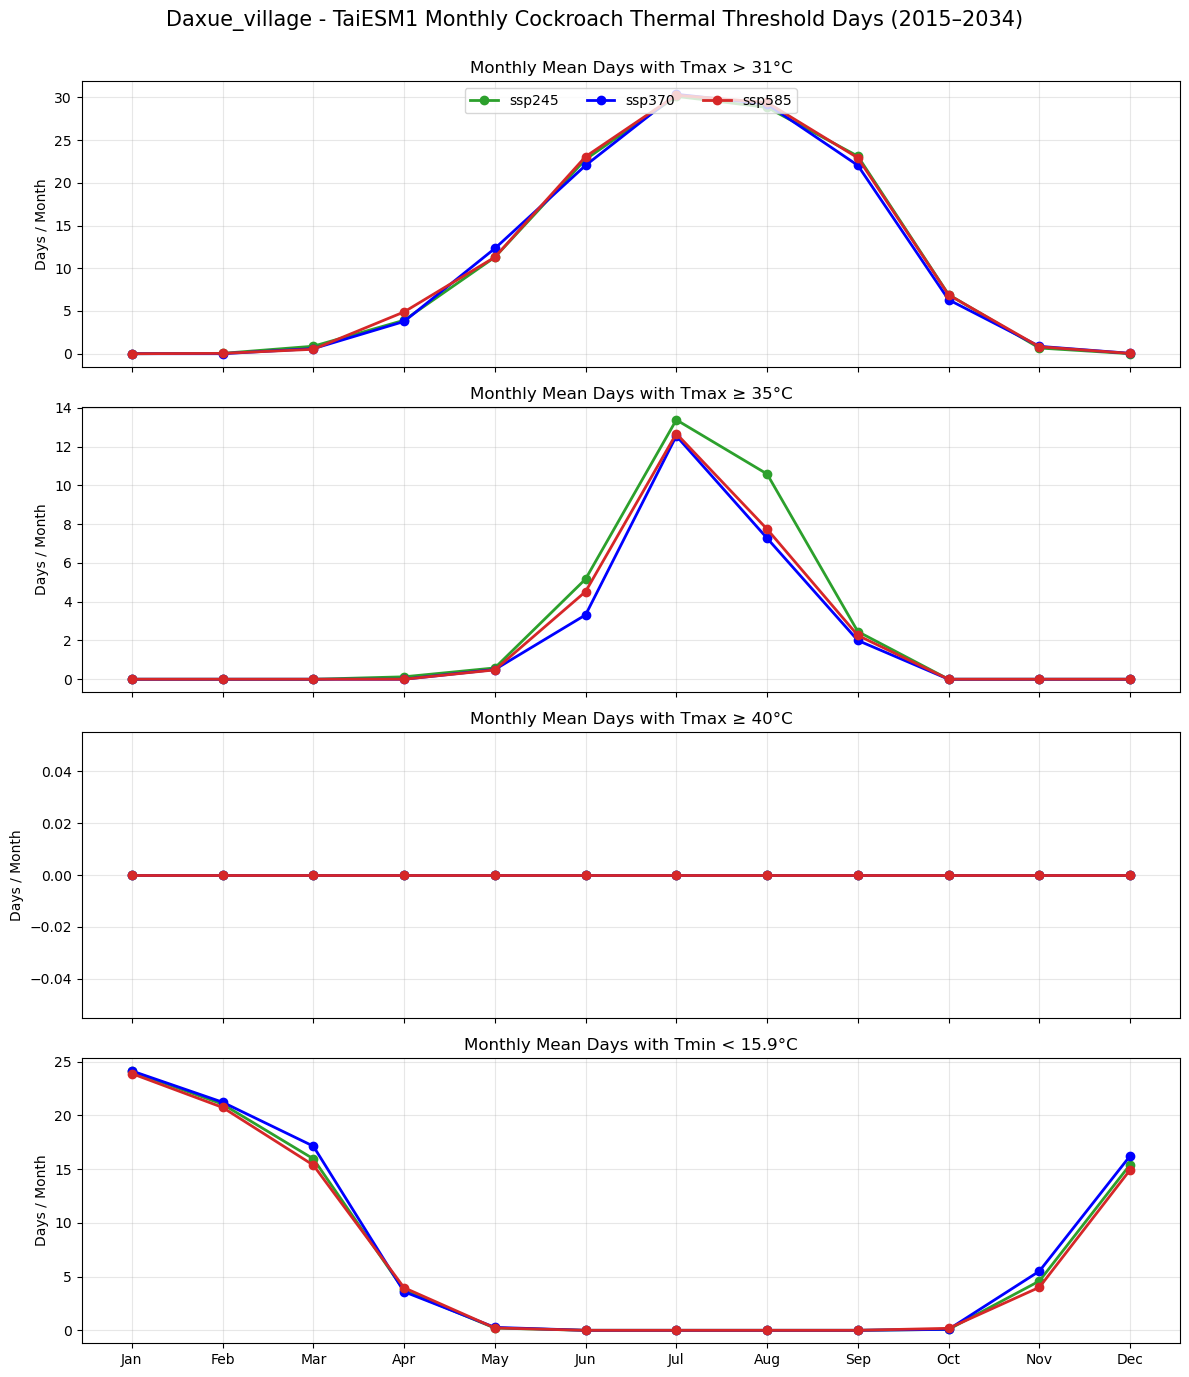

✅ Saved: C:\Climate_project\程式作業\Daxue＿village\figue\Daxue_village_TaiESM1_Seasonal_Mean_Tmean_Interannual_Variation_2004_2034.png


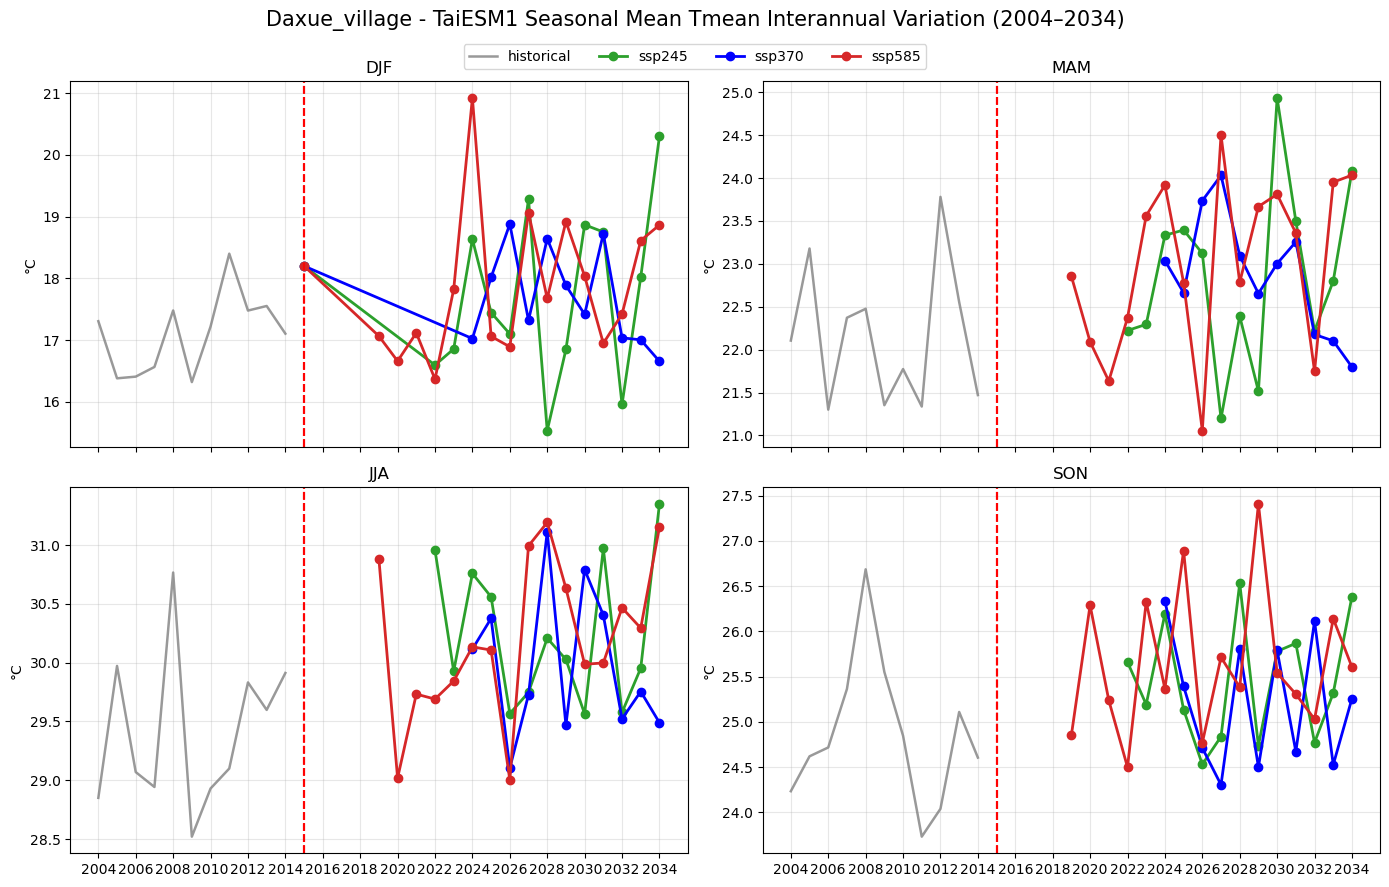

✅ Saved: C:\Climate_project\程式作業\Daxue＿village\figue\Daxue_village_TaiESM1_Seasonal_Days_with_Tmax_gt_31C_Interannual_Variation_2004_2034.png


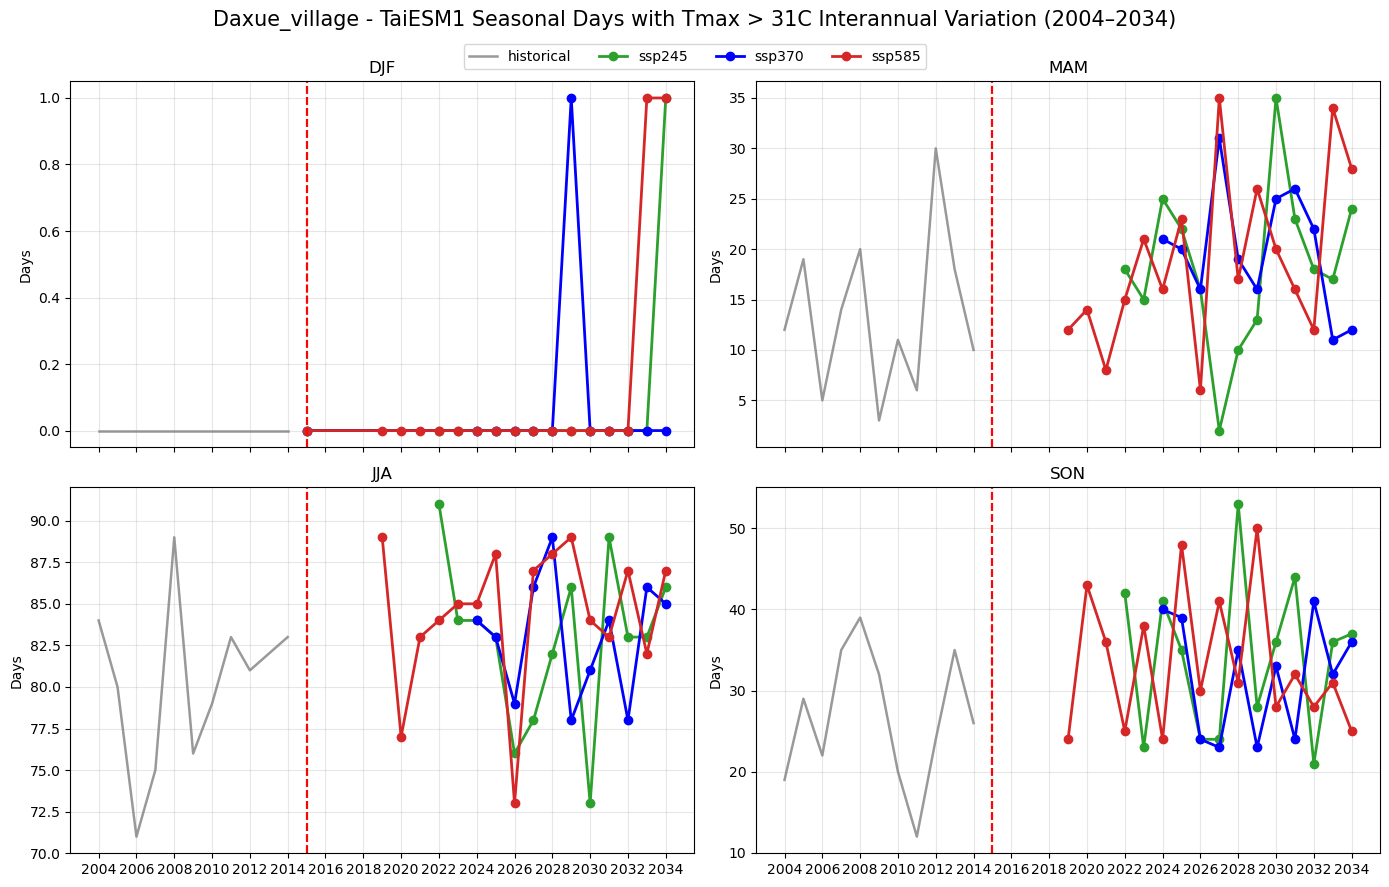

✅ Saved: C:\Climate_project\程式作業\Daxue＿village\figue\Daxue_village_TaiESM1_Seasonal_Days_with_Tmin_lt_15.9C_Interannual_Variation_2004_2034.png


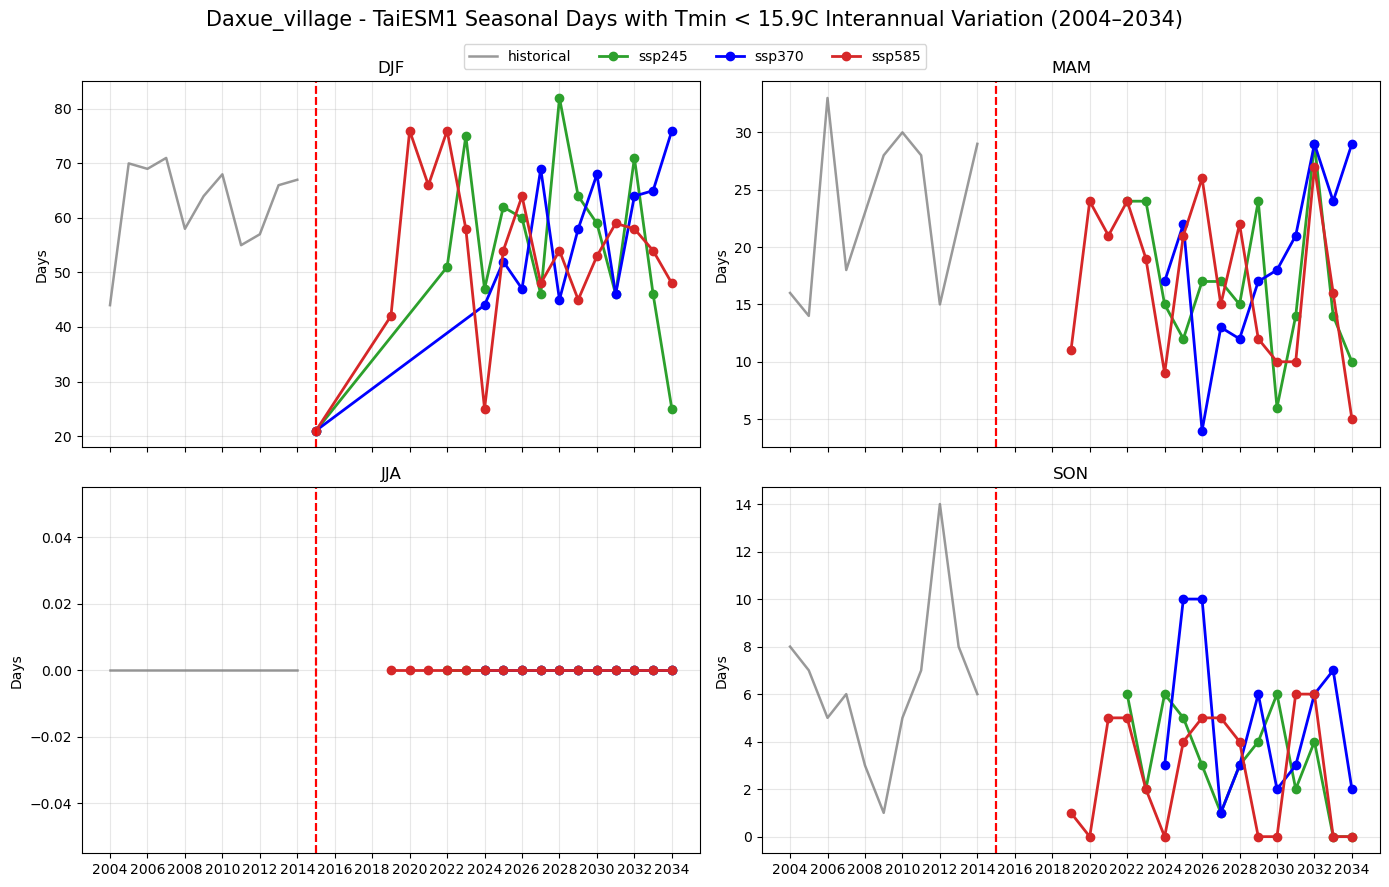

In [2]:
# =========================================================
# 8. 執行畫圖
# =========================================================
plot_seasonal_bar_charts(
    seasonal_results=seasonal_results,
    model_name=model_name,
    save_path=save_path
)

plot_monthly_threshold_lines(
    monthly_results=monthly_results,
    model_name=model_name,
    save_path=save_path
)

plot_seasonal_interannual_timeseries(
    seasonal_results=seasonal_results,
    metric="tmean_seasonal_mean",
    title="Seasonal Mean Tmean Interannual Variation",
    ylabel="°C",
    model_name=model_name,
    save_path=save_path
)

plot_seasonal_interannual_timeseries(
    seasonal_results=seasonal_results,
    metric="tmax_gt31_days",
    title="Seasonal Days with Tmax > 31C Interannual Variation",
    ylabel="Days",
    model_name=model_name,
    save_path=save_path
)

plot_seasonal_interannual_timeseries(
    seasonal_results=seasonal_results,
    metric="tmin_lt15_9_days",
    title="Seasonal Days with Tmin < 15.9C Interannual Variation",
    ylabel="Days",
    model_name=model_name,
    save_path=save_path
)

In [15]:
def plot_seasonal_interannual_timeseries(
    seasonal_results,
    metric,
    title,
    ylabel,
    model_name,
    save_path=None,
    ylim=None,
):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    axes = axes.flatten()

    for i, season in enumerate(season_order):
        ax = axes[i]

        historical_drawn = False
        trend_texts = []

        for ssp in target_ssps:
            if ssp not in seasonal_results:
                continue

            sdf = seasonal_results[ssp].copy()
            sub = sdf[sdf["season"] == season].copy()
            sub = sub[(sub["season_year"] >= start_year) & (sub["season_year"] <= end_year)]

            if len(sub) == 0:
                continue

            hist_part = sub[sub["season_year"] <= 2014].copy()
            fut_part  = sub[sub["season_year"] >= 2015].copy()

            # historical：只畫一次灰色
            if len(hist_part) > 0 and not historical_drawn:
                ax.plot(
                    hist_part["season_year"],
                    hist_part[metric],
                    color="gray",
                    linewidth=1.8,
                    alpha=0.8,
                    label="historical"
                )
                historical_drawn = True

                # ===== historical trend =====
                x_hist = hist_part["season_year"].values
                y_hist = hist_part[metric].values
                mask_hist = ~np.isnan(y_hist)
                x_hist_valid = x_hist[mask_hist]
                y_hist_valid = y_hist[mask_hist]

                if len(x_hist_valid) >= 2:
                    hist_slope, _ = np.polyfit(x_hist_valid, y_hist_valid, 1)
                    trend_texts.append(f"hist: {hist_slope:+.2f}/yr")
                else:
                    trend_texts.append("hist: NA")

            # future：各 SSP 彩色
            if len(fut_part) > 0:
                ax.plot(
                    fut_part["season_year"],
                    fut_part[metric],
                    marker="o",
                    linewidth=2,
                    color=ssp_colors.get(ssp),
                    label=ssp
                )

                # ===== future trend =====
                x_fut = fut_part["season_year"].values
                y_fut = fut_part[metric].values
                mask_fut = ~np.isnan(y_fut)
                x_fut_valid = x_fut[mask_fut]
                y_fut_valid = y_fut[mask_fut]

                if len(x_fut_valid) >= 2:
                    fut_slope, _ = np.polyfit(x_fut_valid, y_fut_valid, 1)
                    trend_texts.append(f"{ssp.replace('ssp','')}: {fut_slope:+.2f}/yr")
                else:
                    trend_texts.append(f"{ssp.replace('ssp','')}: NA")

            # 分界線
            ax.axvline(x=2015, color="red", linestyle="--", linewidth=1.5, alpha=0.8)

        ax.set_title(season)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

        if ylim is not None:
            ax.set_ylim(ylim)

        xticks = np.arange(start_year, end_year + 1, 2)
        ax.set_xticks(xticks)

        # ===== 在圖上印出 trend 數字 =====
        if len(trend_texts) > 0:
            trend_str = "Trend:\n" + "\n".join(trend_texts)
            ax.text(
                0.02, 0.98,
                trend_str,
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=9,
                bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
            )

    handles, labels = axes[0].get_legend_handles_labels()

    # 去重 legend
    uniq = dict(zip(labels, handles))
    fig.legend(
        uniq.values(),
        uniq.keys(),
        loc="upper center",
        ncol=4,
        bbox_to_anchor=(0.5, 0.95)
    )

    fig.suptitle(f"Daxue_village - {model_name} {title} (2004–2034)", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        filename = f"Daxue_village_{model_name}_{safe_filename(title)}_2004_2034.png"
        save_file = save_path / filename
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()

In [16]:
# =========================================================
# 9. 額外分析：不同季節、不同溫度區間的逐年變化
#    （不改主程式，只是額外加功能）
# =========================================================
model_name = "ACCESS-CM2" # ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]
save_path = Path(r"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue")
save_path.mkdir(parents=True, exist_ok=True)

def load_combined_daily_series_for_ssp(model_name, ssp, var_type):
    """
    var_type: 'tmean' / 'tmax' / 'tmin'
    回傳 historical + SSP 接起來的日資料
    """
    if var_type == "tmean":
        hist_folder = tmean_hist_folder
        gwl_folder = tmean_gwl_folder
    elif var_type == "tmax":
        hist_folder = tmax_hist_folder
        gwl_folder = tmax_gwl_folder
    elif var_type == "tmin":
        hist_folder = tmin_hist_folder
        gwl_folder = tmin_gwl_folder
    else:
        raise ValueError("var_type 必須是 'tmean', 'tmax', 或 'tmin'")

    hist_series, _, _ = load_historical_series(hist_folder, model_name, poi_lon, poi_lat)
    fut_series, _, _ = load_gwl_ssp_series(gwl_folder, model_name, ssp, poi_lon, poi_lat)

    combined = combine_historical_and_ssp(hist_series, fut_series)
    combined = combined[(combined.index.year >= start_year) & (combined.index.year <= end_year)]
    return combined


def add_season_columns(df, date_col="date"):
    """
    加入 season 與 season_year
    """
    df = df.copy()
    df["month"] = df[date_col].dt.month
    df["year"] = df[date_col].dt.year
    df["season"] = df["month"].apply(month_to_season)
    df["season_year"] = df.apply(lambda r: assign_season_year(int(r["year"]), int(r["month"])), axis=1)
    return df


def calc_seasonal_interval_count(series, lower=None, upper=None, lower_inclusive=True, upper_inclusive=False):
    """
    計算單一日序列在不同季節的逐年區間日數

    參數
    ----
    series : pd.Series
        index 必須是 DatetimeIndex，value 是溫度
    lower : float or None
        下限
    upper : float or None
        上限
    lower_inclusive : bool
        是否包含下限
    upper_inclusive : bool
        是否包含上限

    回傳
    ----
    seasonal_counts : DataFrame
        欄位: season_year, season, count
    """
    df = pd.DataFrame({
        "date": series.index,
        "value": series.values
    }).dropna()

    df = add_season_columns(df, date_col="date")

    mask = pd.Series(True, index=df.index)

    if lower is not None:
        if lower_inclusive:
            mask &= df["value"] >= lower
        else:
            mask &= df["value"] > lower

    if upper is not None:
        if upper_inclusive:
            mask &= df["value"] <= upper
        else:
            mask &= df["value"] < upper

    df_sel = df[mask].copy()

    seasonal_counts = (
        df_sel.groupby(["season_year", "season"])
        .size()
        .reset_index(name="count")
    )

    # 補齊沒有出現的 season-year 組合，讓畫圖不會斷掉
    all_years = range(start_year, end_year + 1)
    full_index = pd.MultiIndex.from_product(
        [all_years, season_order],
        names=["season_year", "season"]
    )

    seasonal_counts = (
        seasonal_counts.set_index(["season_year", "season"])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )

    seasonal_counts["season"] = pd.Categorical(
        seasonal_counts["season"],
        categories=season_order,
        ordered=True
    )

    return seasonal_counts


def build_interval_results(model_name, target_ssps, var_type, lower=None, upper=None,
                           lower_inclusive=True, upper_inclusive=False):
    """
    對所有 SSP 建立某一溫度區間的季節逐年日數結果
    """
    interval_results = {}

    for ssp in target_ssps:
        try:
            s = load_combined_daily_series_for_ssp(model_name, ssp, var_type)
            out = calc_seasonal_interval_count(
                s,
                lower=lower,
                upper=upper,
                lower_inclusive=lower_inclusive,
                upper_inclusive=upper_inclusive
            )
            interval_results[ssp] = out
            print(f"[OK] {var_type} | {ssp} | lower={lower} upper={upper}")
        except Exception as e:
            print(f"[SKIP] {var_type} | {ssp}: {e}")

    return interval_results


def make_interval_label(var_type, lower=None, upper=None,
                        lower_inclusive=True, upper_inclusive=False):
    """
    自動產生圖標題與檔名用文字
    """
    if lower is None and upper is None:
        return f"{var_type}_all"

    if lower is not None and upper is not None:
        left = ">=" if lower_inclusive else ">"
        right = "<=" if upper_inclusive else "<"
        return f"{var_type}_{left}_{lower}_{right}_{upper}"

    if lower is not None:
        left = ">=" if lower_inclusive else ">"
        return f"{var_type}_{left}_{lower}"

    if upper is not None:
        right = "<=" if upper_inclusive else "<"
        return f"{var_type}_{right}_{upper}"

    return f"{var_type}_custom"



def plot_interval_seasonal_interannual(
    interval_results,
    title,
    ylabel="Days",
    model_name=model_name,
    save_path=save_path,
    ylim=None
):
    """
    畫：不同季節、不同溫度區間的逐年變化 + 顯示 trend 數值
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    axes = axes.flatten()

    for i, season in enumerate(season_order):
        ax = axes[i]
        historical_drawn = False
        trend_texts = []

        for ssp in target_ssps:
            if ssp not in interval_results:
                continue

            df = interval_results[ssp].copy()
            sub = df[df["season"] == season].copy()

            if len(sub) == 0:
                continue

            hist_part = sub[sub["season_year"] <= 2014].copy()
            fut_part  = sub[sub["season_year"] >= 2015].copy()

            # ===== historical =====
            if len(hist_part) > 0 and not historical_drawn:
                ax.plot(
                    hist_part["season_year"],
                    hist_part["count"],
                    color="gray",
                    linewidth=1.8,
                    alpha=0.8,
                    label="historical"
                )
                historical_drawn = True

                # --- trend ---
                x_hist = hist_part["season_year"].values
                y_hist = hist_part["count"].values
                mask = ~np.isnan(y_hist)

                if np.sum(mask) >= 2:
                    slope, _ = np.polyfit(x_hist[mask], y_hist[mask], 1)
                    trend_texts.append(f"hist: {slope:+.2f}/yr")
                else:
                    trend_texts.append("hist: NA")

            # ===== future =====
            if len(fut_part) > 0:
                ax.plot(
                    fut_part["season_year"],
                    fut_part["count"],
                    marker="o",
                    linewidth=2,
                    color=ssp_colors.get(ssp),
                    label=ssp
                )

                # --- trend ---
                x_fut = fut_part["season_year"].values
                y_fut = fut_part["count"].values
                mask = ~np.isnan(y_fut)

                if np.sum(mask) >= 2:
                    slope, _ = np.polyfit(x_fut[mask], y_fut[mask], 1)
                    trend_texts.append(f"{ssp.replace('ssp','')}: {slope:+.2f}/yr")
                else:
                    trend_texts.append(f"{ssp.replace('ssp','')}: NA")

            # 分界線
            ax.axvline(x=2015, color="red", linestyle="--", linewidth=1.5, alpha=0.8)

        ax.set_title(season)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

        if ylim is not None:
            ax.set_ylim(ylim)

        xticks = np.arange(start_year, end_year + 1, 2)
        ax.set_xticks(xticks)

        # ===== 顯示 trend =====
        if len(trend_texts) > 0:
            trend_str = "Trend:\n" + "\n".join(trend_texts)
            ax.text(
                0.02, 0.98,
                trend_str,
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=9,
                bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
            )

    # legend
    handles, labels = axes[0].get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    fig.legend(
        uniq.values(),
        uniq.keys(),
        loc="upper center",
        ncol=4,
        bbox_to_anchor=(0.5, 0.95)
    )

    fig.suptitle(f"Daxue_village - {model_name} {title} ({start_year}–{end_year})", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        filename = f"Daxue_village_{model_name}_{safe_filename(title)}_{start_year}_{end_year}.png"
        save_file = save_path / filename
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()    

[OK] tmin | ssp245 | lower=None upper=15.9
[OK] tmin | ssp370 | lower=None upper=15.9
[OK] tmin | ssp585 | lower=None upper=15.9
✅ Saved: C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\Daxue_village_ACCESS-CM2_Seasonal_Days_with_15.9_lteq_Tmin_2004_2034.png


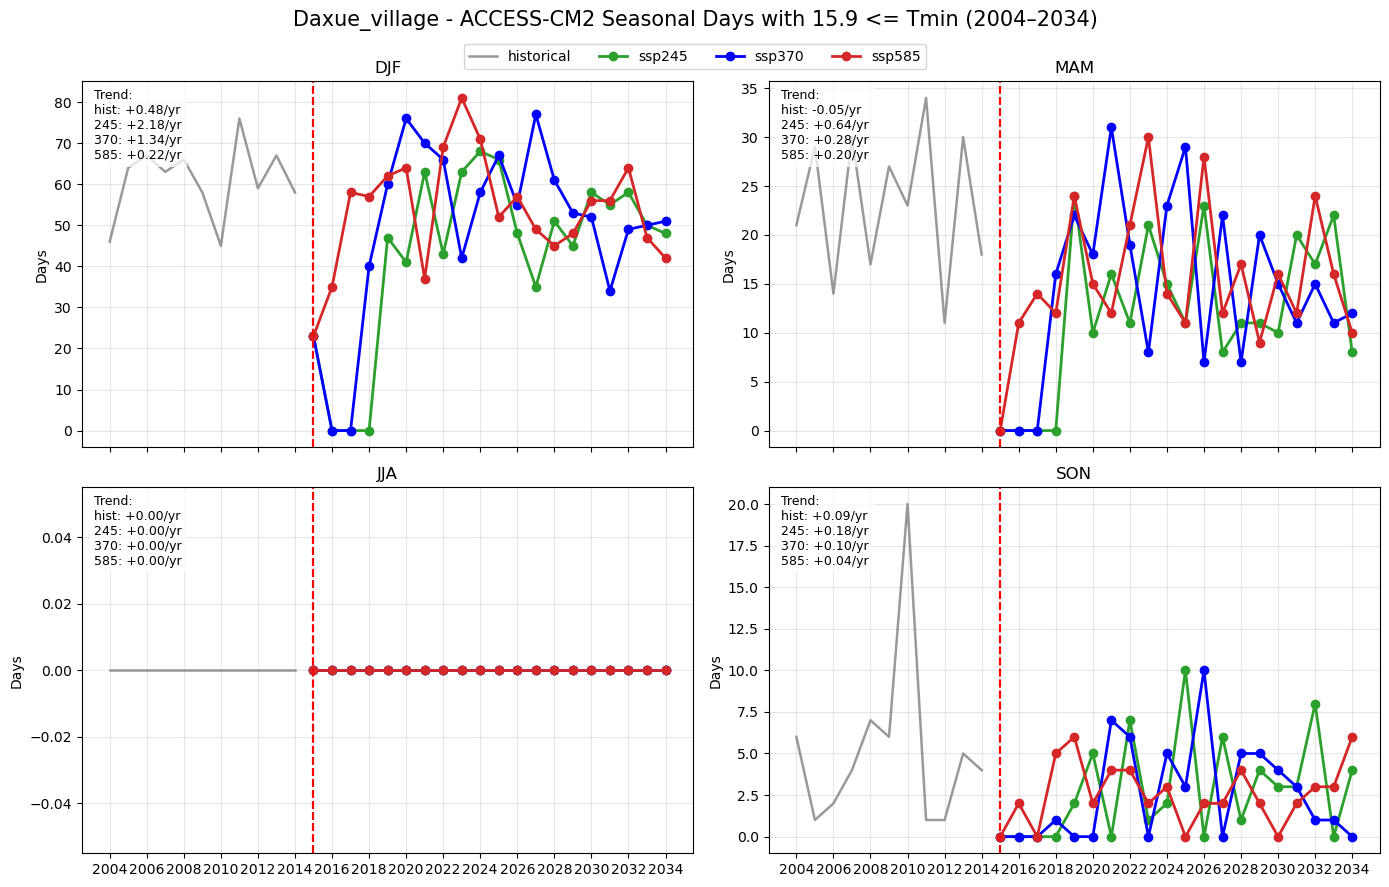

In [17]:
model_name = "ACCESS-CM2" # ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]

interval_tmax_31_35 = build_interval_results(
    model_name=model_name,
    target_ssps=target_ssps,
    var_type="tmin",
    lower=None,
    upper=15.9,
    lower_inclusive=True,
    upper_inclusive=False
)

plot_interval_seasonal_interannual(
    interval_results=interval_tmax_31_35,
    title="Seasonal Days with 15.9 <= Tmin", # < 31C
    save_path=save_path,
    ylabel="Days"
)

In [6]:
print(seasonal_results.keys())

dict_keys([])


In [10]:
def plot_interval_seasonal_interannual(
    interval_results,
    title,
    ylabel="Days",
    model_name=model_name,
    save_path=save_path,
    ylim=None
):
    """
    畫：不同季節、不同溫度區間的逐年變化 + 顯示 trend 數值
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    axes = axes.flatten()

    for i, season in enumerate(season_order):
        ax = axes[i]
        historical_drawn = False
        trend_texts = []

        for ssp in target_ssps:
            if ssp not in interval_results:
                continue

            df = interval_results[ssp].copy()
            sub = df[df["season"] == season].copy()

            if len(sub) == 0:
                continue

            hist_part = sub[sub["season_year"] <= 2014].copy()
            fut_part  = sub[sub["season_year"] >= 2015].copy()

            # ===== historical =====
            if len(hist_part) > 0 and not historical_drawn:
                ax.plot(
                    hist_part["season_year"],
                    hist_part["count"],
                    color="gray",
                    linewidth=1.8,
                    alpha=0.8,
                    label="historical"
                )
                historical_drawn = True

                # --- trend ---
                x_hist = hist_part["season_year"].values
                y_hist = hist_part["count"].values
                mask = ~np.isnan(y_hist)

                if np.sum(mask) >= 2:
                    slope, _ = np.polyfit(x_hist[mask], y_hist[mask], 1)
                    trend_texts.append(f"hist: {slope:+.2f}/yr")
                else:
                    trend_texts.append("hist: NA")

            # ===== future =====
            if len(fut_part) > 0:
                ax.plot(
                    fut_part["season_year"],
                    fut_part["count"],
                    marker="o",
                    linewidth=2,
                    color=ssp_colors.get(ssp),
                    label=ssp
                )

                # --- trend ---
                x_fut = fut_part["season_year"].values
                y_fut = fut_part["count"].values
                mask = ~np.isnan(y_fut)

                if np.sum(mask) >= 2:
                    slope, _ = np.polyfit(x_fut[mask], y_fut[mask], 1)
                    trend_texts.append(f"{ssp.replace('ssp','')}: {slope:+.2f}/yr")
                else:
                    trend_texts.append(f"{ssp.replace('ssp','')}: NA")

            # 分界線
            ax.axvline(x=2015, color="red", linestyle="--", linewidth=1.5, alpha=0.8)

        ax.set_title(season)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

        if ylim is not None:
            ax.set_ylim(ylim)

        xticks = np.arange(start_year, end_year + 1, 2)
        ax.set_xticks(xticks)

        # ===== 顯示 trend =====
        if len(trend_texts) > 0:
            trend_str = "Trend:\n" + "\n".join(trend_texts)
            ax.text(
                0.02, 0.98,
                trend_str,
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=9,
                bbox=dict(facecolor="white", alpha=0.75, edgecolor="none")
            )

    # legend
    handles, labels = axes[0].get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    fig.legend(
        uniq.values(),
        uniq.keys(),
        loc="upper center",
        ncol=4,
        bbox_to_anchor=(0.5, 0.95)
    )

    fig.suptitle(f"Daxue_village - {model_name} {title} ({start_year}–{end_year})", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        filename = f"Daxue_village_{model_name}_{safe_filename(title)}_{start_year}_{end_year}.png"
        save_file = save_path / filename
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()